<div dir="rtl">

# تعریف مسئله و متغیر هدف

در این بخش، هدف اصلی مشخص کردن دقیق مسئله‌ی پیش‌بینی است. از آن‌جا که مجموعه‌داده شامل آگهی‌های مختلف فروش، رهن و اجاره است، لازم است پیش از آموزش مدل تعیین شود که مدل قرار است دقیقاً چه مقدار مالی‌ای را پیش‌بینی کند.

برای این منظور، ابتدا انواع معامله‌های موجود در داده بررسی می‌شوند و سپس برای هر نوع معامله، ستون مناسب به‌عنوان متغیر هدف (`Target`) انتخاب خواهد شد.

مواردی که در این مرحله بررسی می‌شوند شامل موارد زیر هستند:

1. تعیین نوع مسئله‌ی پیش‌بینی برای آگهی‌های فروش و اجاره.
2. مشخص کردن ستون مناسب قیمت برای آگهی‌های فروش.
3. مشخص کردن مقدار مالی مناسب برای آگهی‌های رهن و اجاره.
4. بررسی امکان استفاده از یک مدل مشترک یا مدل‌های جداگانه برای انواع معامله.
5. بررسی تعداد داده‌های دارای Target معتبر برای هر گروه.
6. مشخص کردن داده‌هایی که به دلیل نداشتن Target معتبر، قابل استفاده در مدل‌سازی نیستند.

هدف این مرحله، رسیدن به یک تعریف شفاف و قابل دفاع از متغیر هدف است تا در مراحل بعدی، انتخاب Featureها، تقسیم داده و آموزش مدل بر اساس همین تعریف انجام شود.

</div>

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_parquet("../data/Divar_cleaned.parquet")


In [3]:
valid_transaction_types = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

model_df = df[df["cat2_slug"].isin(valid_transaction_types)].copy()

print("Rows before filtering:", len(df))
print("Rows after filtering:", len(model_df))

print("\nSelected transaction types:")
print(model_df["cat2_slug"].value_counts())

Rows before filtering: 999997
Rows after filtering: 950691

Selected transaction types:
cat2_slug
residential-sell    558707
residential-rent    276558
commercial-rent      76565
commercial-sell      38861
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### بررسی آگهی‌های اجاره کوتاه‌مدت

در این مرحله، آگهی‌های دسته‌ی `temporary-rent` به‌صورت جداگانه بررسی شدند تا مشخص شود آیا می‌توان برای آن‌ها نیز متغیر هدف مشترک `unified_price` را تعریف کرد یا خیر.

تعداد کل آگهی‌های اجاره کوتاه‌مدت برابر با **29,903** ردیف بود.

بررسی ستون‌های مالی نشان داد:

- تنها **5** ردیف دارای `price_value` بودند.
- تنها **3** ردیف دارای `credit_value` بودند.
- تنها **3** ردیف دارای `rent_value` بودند.
- ستون‌های `transformable_credit`، `transformed_credit`، `transformable_rent` و `transformed_rent` برای تمام این دسته فاقد مقدار بودند.
- ستون `rent_type` نیز تنها برای **2** ردیف مقدار داشت.
- `inferred_full_credit` نیز فقط برای **2** ردیف قابل تشخیص بود.

بنابراین تقریباً تمام آگهی‌های `temporary-rent` فاقد اطلاعات مالی لازم برای ساخت `unified_price` هستند.

در نتیجه، با وجود اینکه اجاره کوتاه‌مدت از نظر مفهومی جزو معاملات اجاره محسوب می‌شود، در این دیتاست امکان تعریف یک Target مالی قابل اتکا برای آن وجود ندارد. به همین دلیل، این دسته از داده‌های مورد استفاده برای مدل پیش‌بینی حذف می‌شود.

همچنین دسته‌ی `real-estate-services` نیز به دلیل اینکه مربوط به خدمات حوزه املاک است و نه معامله مستقیم یک ملک، وارد مدل نخواهد شد.

در نتیجه، انواع معامله‌ی مورد استفاده در مدل عبارت‌اند از:

- `residential-sell`
- `commercial-sell`
- `residential-rent`
- `commercial-rent`

</div>

In [4]:

is_sell = model_df["cat2_slug"].str.contains("sell", na=False)

is_full_credit = (
    (model_df["inferred_full_credit"] == True)
    .fillna(False)
)

conditions = [
    is_sell,
    is_full_credit
]

choices = [
    model_df["price_value"],
    model_df["transformable_credit"]
]

model_df["unified_price"] = np.select(
    conditions,
    choices,
    default=model_df["transformed_credit"]
)

# Zero cannot be used as a valid target
model_df["unified_price"] = model_df["unified_price"].replace(0, np.nan)

In [5]:
valid_target = model_df["unified_price"].notna()

print("Total modeling rows:", len(model_df))
print("Valid targets:", valid_target.sum())
print("Missing targets:", (~valid_target).sum())
print(
    "Target coverage:",
    round(valid_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")
print(
    model_df.loc[valid_target, "cat2_slug"]
    .value_counts()
)

Total modeling rows: 950691
Valid targets: 680999
Missing targets: 269692
Target coverage: 71.63 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    104051
commercial-sell      31929
commercial-rent      11759
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

### تعریف نهایی مسئله و متغیر هدف

در این پروژه یک مدل رگرسیون مشترک برای پیش‌بینی ارزش مالی آگهی‌های املاک در نظر گرفته شد.

چهار نوع معامله در داده‌های مدل نگه داشته شدند:

- فروش مسکونی
- فروش تجاری
- اجاره مسکونی
- اجاره تجاری

دسته‌ی `real-estate-services` به دلیل مربوط بودن به خدمات املاک و دسته‌ی `temporary-rent` به دلیل نبود اطلاعات مالی کافی برای تعریف متغیر هدف، از داده‌های مدل حذف شدند.

متغیر هدف مدل با نام `unified_price` تعریف شد تا انواع مختلف معاملات دارای یک Target عددی مشترک باشند.

منطق ساخت متغیر هدف به شکل زیر است:

- در آگهی‌های فروش از `price_value` استفاده می‌شود.
- در آگهی‌های رهن کامل، که با `inferred_full_credit` تشخیص داده می‌شوند، از `transformable_credit` استفاده می‌شود.
- در سایر آگهی‌های اجاره از `transformed_credit` استفاده می‌شود.
- مقادیر صفر به‌عنوان Target معتبر در نظر گرفته نمی‌شوند.

همچنین نوع معامله (`cat2_slug`) در مراحل بعدی به‌عنوان یکی از ویژگی‌های ورودی مدل استفاده خواهد شد تا مدل بتواند تفاوت میان انواع معاملات را تشخیص دهد.

</div>

<div dir="rtl">

# تسک ۲ — ساخت دیتاست نهایی مدل و بررسی کیفیت Target

در این مرحله، متغیر هدف نهایی برای مدل ساخته و کیفیت آن بررسی می‌شود.

اهداف این بخش:

- بررسی Targetهای گمشده
- بازیابی Targetهایی که از اطلاعات مالی موجود قابل محاسبه هستند
- ساخت Target نهایی برای فروش و اجاره
- بررسی مقادیر غیرعادی و Outlierها
- ساخت دیتاست نهایی مخصوص مدل‌سازی
- حفظ داده‌های اصلی بدون تغییر

در این مرحله Outlierها شناسایی می‌شوند، اما برای جلوگیری از نشت اطلاعات، مرزهای نهایی Capping بعد از تقسیم Train / Validation / Test و فقط بر اساس Train محاسبه خواهند شد.

</div>

In [6]:
missing_target_df = model_df[
    model_df["unified_price"].isna()
].copy()

print("Total missing targets:", len(missing_target_df))

print("\nMissing targets by transaction type:")
print(missing_target_df["cat2_slug"].value_counts())

Total missing targets: 269692

Missing targets by transaction type:
cat2_slug
residential-rent    172507
commercial-rent      64806
residential-sell     25447
commercial-sell       6932
Name: count, dtype: int64[pyarrow]


In [7]:
check_cols = [
    "price_value",
    "credit_value",
    "rent_value",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",
    "rent_type",
    "rent_credit_transform",
    "inferred_full_credit"
]

for category in missing_target_df["cat2_slug"].dropna().unique():

    subset = missing_target_df[
        missing_target_df["cat2_slug"] == category
    ]

    print("\n" + "=" * 70)
    print("Category:", category)
    print("Rows:", len(subset))

    for col in check_cols:
        print(
            f"{col:25s} -> "
            f"{subset[col].notna().sum():,} non-null"
        )


Category: residential-rent
Rows: 172507
price_value               -> 6 non-null
credit_value              -> 172,033 non-null
rent_value                -> 171,269 non-null
transformable_credit      -> 172,033 non-null
transformed_credit        -> 19 non-null
transformable_rent        -> 171,268 non-null
transformed_rent          -> 19 non-null
rent_type                 -> 48,438 non-null
rent_credit_transform     -> 172,483 non-null
inferred_full_credit      -> 171,271 non-null

Category: commercial-rent
Rows: 64806
price_value               -> 34 non-null
credit_value              -> 64,240 non-null
rent_value                -> 64,231 non-null
transformable_credit      -> 64,240 non-null
transformed_credit        -> 17 non-null
transformable_rent        -> 64,227 non-null
transformed_rent          -> 17 non-null
rent_type                 -> 14,687 non-null
rent_credit_transform     -> 64,691 non-null
inferred_full_credit      -> 64,263 non-null

Category: residential-sell
Rows: 25447

In [8]:
conversion_df = model_df[
    model_df["credit_value"].notna()
    & model_df["rent_value"].notna()
    & model_df["transformed_credit"].notna()
    & model_df["transformed_rent"].notna()
].copy()

denominator = (
    conversion_df["rent_value"]
    - conversion_df["transformed_rent"]
)

valid_conversion = denominator != 0

conversion_df = conversion_df.loc[
    valid_conversion
].copy()

conversion_df["conversion_rate"] = (
    (
        conversion_df["transformed_credit"]
        - conversion_df["credit_value"]
    )
    /
    (
        conversion_df["rent_value"]
        - conversion_df["transformed_rent"]
    )
)

valid_rates = conversion_df.loc[
    (conversion_df["conversion_rate"] > 0)
    & np.isfinite(conversion_df["conversion_rate"]),
    "conversion_rate"
]

conversion_rate = valid_rates.median()

print("Valid conversion rows:", len(valid_rates))
print("Median conversion rate:", conversion_rate)

Valid conversion rows: 72409
Median conversion rate: 33.333333333333336


In [9]:
model_ready_df = model_df.copy()

is_sell = model_ready_df["cat2_slug"].str.contains(
    "sell",
    na=False
)

is_rent = model_ready_df["cat2_slug"].str.contains(
    "rent",
    na=False
)

model_ready_df["unified_price_final"] = np.nan


# Sale
valid_sell = (
    is_sell
    & model_ready_df["price_value"].notna()
    & (model_ready_df["price_value"] > 0)
)

model_ready_df.loc[
    valid_sell,
    "unified_price_final"
] = model_ready_df.loc[
    valid_sell,
    "price_value"
]


# Rent / Full Credit
valid_rent = (
    is_rent
    & model_ready_df["credit_value"].notna()
    & model_ready_df["rent_value"].notna()
)

model_ready_df.loc[
    valid_rent,
    "unified_price_final"
] = (
    model_ready_df.loc[
        valid_rent,
        "credit_value"
    ]
    +
    model_ready_df.loc[
        valid_rent,
        "rent_value"
    ] * conversion_rate
)

In [10]:
valid_final_target = (
    model_ready_df["unified_price_final"].notna()
)

print("Total rows:", len(model_ready_df))

print(
    "Valid final targets:",
    valid_final_target.sum()
)

print(
    "Missing final targets:",
    (~valid_final_target).sum()
)

print(
    "Coverage:",
    round(valid_final_target.mean() * 100, 2),
    "%"
)

print("\nValid targets by transaction type:")

print(
    model_ready_df.loc[
        valid_final_target,
        "cat2_slug"
    ].value_counts()
)

Total rows: 950691
Valid final targets: 916369
Missing final targets: 34322
Coverage: 96.39 %

Valid targets by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


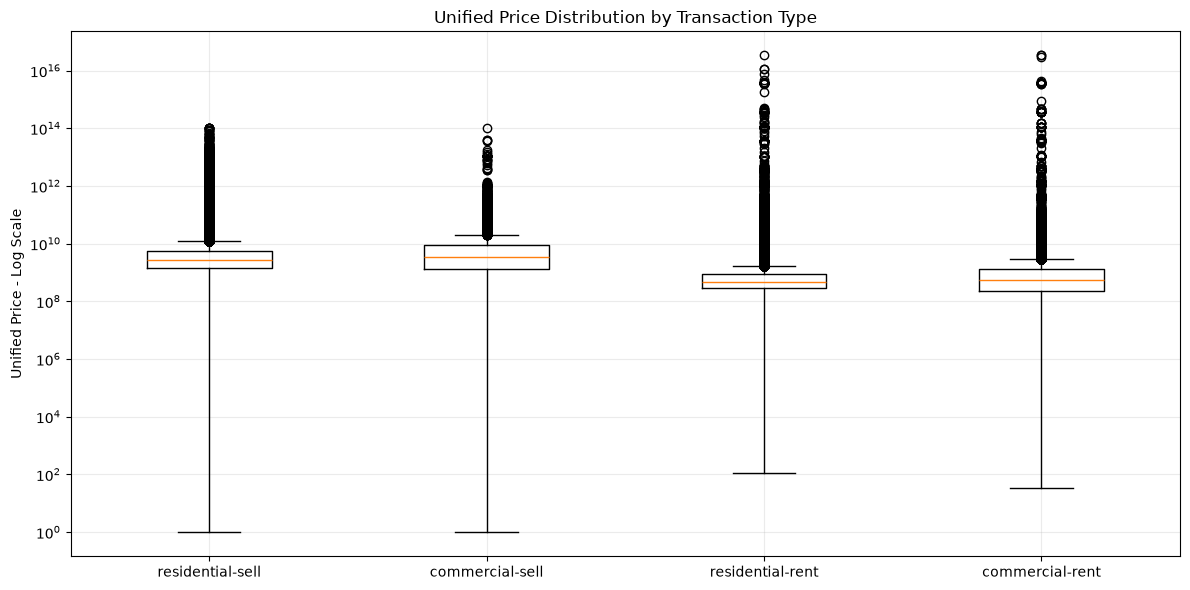

In [11]:
import matplotlib.pyplot as plt

box_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

category_order = [
    "residential-sell",
    "commercial-sell",
    "residential-rent",
    "commercial-rent"
]

data = []

for cat in category_order:

    values = pd.to_numeric(
        box_df.loc[
            box_df["cat2_slug"] == cat,
            "unified_price_final"
        ],
        errors="coerce"
    ).dropna().astype(float).to_numpy()

    data.append(values)

plt.figure(figsize=(12, 6))

plt.boxplot(
    data,
    tick_labels=category_order,
    showfliers=True
)

plt.yscale("log")

plt.title(
    "Unified Price Distribution by Transaction Type"
)

plt.ylabel(
    "Unified Price - Log Scale"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.show()

In [12]:
outlier_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

outlier_df["log_target"] = np.log1p(
    outlier_df["unified_price_final"]
)

outlier_df["extreme_outlier"] = False

for cat in outlier_df["cat2_slug"].unique():

    mask = outlier_df["cat2_slug"] == cat

    values = outlier_df.loc[
        mask,
        "log_target"
    ]

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 3 * iqr
    upper = q3 + 3 * iqr

    outlier_df.loc[
        mask
        & (
            (outlier_df["log_target"] < lower)
            | (outlier_df["log_target"] > upper)
        ),
        "extreme_outlier"
    ] = True


print(
    "Total valid targets:",
    len(outlier_df)
)

print(
    "Extreme outliers:",
    outlier_df["extreme_outlier"].sum()
)

print(
    "\nExtreme outliers by category:"
)

print(
    outlier_df.loc[
        outlier_df["extreme_outlier"],
        "cat2_slug"
    ].value_counts()
)

Total valid targets: 916369
Extreme outliers: 16600

Extreme outliers by category:
cat2_slug
residential-sell    11991
residential-rent     2514
commercial-sell      1632
commercial-rent       463
Name: count, dtype: int64[pyarrow]


In [13]:
model_ready_df["extreme_outlier"] = False

model_ready_df.loc[
    outlier_df.index,
    "extreme_outlier"
] = outlier_df["extreme_outlier"]

print(
    "Extreme outliers:",
    model_ready_df["extreme_outlier"].sum()
)

Extreme outliers: 16600


In [14]:
before = len(model_ready_df)

model_ready_df = model_ready_df[
    model_ready_df["unified_price_final"].notna()
].copy()

removed = before - len(model_ready_df)

print(
    "Rows before target cleaning:",
    before
)

print(
    "Final modeling rows:",
    len(model_ready_df)
)

print(
    "Removed missing targets:",
    removed
)

print(
    "Missing targets:",
    model_ready_df[
        "unified_price_final"
    ].isna().sum()
)

print(
    "Extreme outliers flagged:",
    model_ready_df[
        "extreme_outlier"
    ].sum()
)

print(
    "\nFinal rows by transaction type:"
)

print(
    model_ready_df[
        "cat2_slug"
    ].value_counts()
)

Rows before target cleaning: 950691
Final modeling rows: 916369
Removed missing targets: 34322
Missing targets: 0
Extreme outliers flagged: 16600

Final rows by transaction type:
cat2_slug
residential-sell    533260
residential-rent    275264
commercial-rent      75916
commercial-sell      31929
Name: count, dtype: int64[pyarrow]


In [15]:
# Rule-based target validation

target = pd.to_numeric(
    model_ready_df["unified_price_final"],
    errors="coerce"
)

is_sell = model_ready_df["cat2_slug"].str.contains(
    "sell",
    na=False
)

# Sale prices below 100 million
low_sale_price = (
    is_sell
    & target.notna()
    & (target < 100_000_000)
)

# Convert explicitly to Python string
# because PyArrow regex does not support backreferences such as \1
target_string = (
    target.round()
    .astype("Int64")
    .astype("string[python]")
)

# Suspicious repeated-digit prices:
# 9999999, 1111111111, 777777777, ...
repeated_digit_price = (
    is_sell
    & target_string.str.fullmatch(
        r"([1-9])\1{6,}",
        na=False
    )
)

rule_based_invalid_target = (
    low_sale_price
    | repeated_digit_price
)

print(
    "Sale prices below 100M:",
    low_sale_price.sum()
)

print(
    "Repeated-digit suspicious prices:",
    repeated_digit_price.sum()
)

print(
    "Total rule-based invalid targets:",
    rule_based_invalid_target.sum()
)

display(
    model_ready_df.loc[
        rule_based_invalid_target,
        [
            "cat2_slug",
            "unified_price_final"
        ]
    ].head(20)
)

Sale prices below 100M: 14961
Repeated-digit suspicious prices: 10618
Total rule-based invalid targets: 23110


,cat2_slug,unified_price_final
56,commercial-sell,1.000000e+02
69,residential-sell,1.111111e+08
93,residential-sell,2.730000e+06
129,residential-sell,1.111111e+09
242,residential-sell,1.111112e+06
262,commercial-sell,1.000000e+00
280,residential-sell,1.111111e+08
305,residential-sell,1.110000e+02
329,residential-sell,1.111111e+10
367,residential-sell,1.234500e+04


In [16]:
before = len(model_ready_df)

invalid_target_df = model_ready_df.loc[
    rule_based_invalid_target
].copy()

model_ready_df = model_ready_df.loc[
    ~rule_based_invalid_target
].copy()

print("Rows before rule-based validation:", before)

print(
    "Removed invalid targets:",
    len(invalid_target_df)
)

print(
    "Final modeling rows:",
    len(model_ready_df)
)

print(
    "\nFinal rows by transaction type:"
)

print(
    model_ready_df["cat2_slug"].value_counts()
)

Rows before rule-based validation: 916369
Removed invalid targets: 23110
Final modeling rows: 893259

Final rows by transaction type:
cat2_slug
residential-sell    512944
residential-rent    275264
commercial-rent      75916
commercial-sell      29135
Name: count, dtype: int64[pyarrow]


<div dir="rtl">

# جمع‌بندی نهایی تسک ۲ — ساخت و اعتبارسنجی متغیر هدف

هدف این مرحله، ساخت یک متغیر هدف عددی، قابل مقایسه و قابل استفاده برای آموزش مدل رگرسیون بود؛ به‌گونه‌ای که تفاوت ساختاری میان معاملات فروش، رهن کامل و رهن‌واجاره باعث از دست رفتن بخش بزرگی از داده‌ها نشود.

---

## ۱. مشکل تعریف اولیه‌ی Target

در تعریف اولیه، برای فروش از `price_value` و برای بخش اجاره عمدتاً از ستون‌های تبدیل‌شده مانند `transformed_credit` استفاده شده بود.

این تعریف باعث شد از مجموع **950,691** رکورد انتخاب‌شده، تنها **680,999** رکورد دارای Target معتبر باشند و پوشش Target برابر با **71.63٪** شود.

بررسی دقیق‌تر نشان داد بخش قابل توجهی از Missing Targetها واقعاً فاقد اطلاعات مالی نبودند. برای مثال، تعداد زیادی از آگهی‌های اجاره دارای مقادیر معتبر `credit_value` و `rent_value` بودند، اما چون ستون `transformed_credit` تنها در بخشی از داده‌ها مقدار داشت، Target آن‌ها به اشتباه Missing شده بود.

بنابراین Missing بودن `transformed_credit` لزوماً به معنای نبود اطلاعات مالی قابل استفاده نبود.

---

## ۲. تعریف Target برای آگهی‌های فروش

برای معاملات فروش، متغیر هدف مستقیماً از:

`price_value`

گرفته شد.

این انتخاب مستقیم‌ترین تعریف ممکن است، زیرا `price_value` مبلغ اعلام‌شده برای فروش ملک است و نیاز به تبدیل مالی دیگری ندارد.

مقادیر صفر یا Missing به‌عنوان Target معتبر در نظر گرفته نشدند.

---

## ۳. یکپارچه‌سازی رهن و اجاره

آگهی‌های اجاره معمولاً دارای دو جزء مالی هستند:

- مبلغ رهن یا ودیعه (`credit_value`)
- مبلغ اجاره (`rent_value`)

از آن‌جا که مدل باید یک خروجی عددی واحد داشته باشد، برای معاملات اجاره یک **ارزش معادل رهن** تعریف شد:

`Equivalent Credit = credit_value + rent_value × conversion_rate`

در نتیجه، تمام حالت‌های اجاره روی یک مقیاس مالی مشترک قرار گرفتند.

این رابطه رهن کامل را نیز به‌طور طبیعی پوشش می‌دهد، زیرا در رهن کامل:

`rent_value = 0`

و در نتیجه:

`Equivalent Credit = credit_value`

---

## ۴. استخراج نرخ تبدیل از خود دیتاست

به‌جای استفاده از یک نرخ قراردادی ثابت، نرخ تبدیل با استفاده از رکوردهایی محاسبه شد که مقادیر اولیه و تبدیل‌شده‌ی رهن و اجاره را هم‌زمان داشتند.

نرخ تبدیل با استفاده از:

`credit_value`

`rent_value`

`transformed_credit`

`transformed_rent`

استخراج شد.

سپس **Median** نرخ‌های معتبر به‌عنوان نرخ تبدیل نهایی استفاده شد.

Median نسبت به Mean در برابر داده‌های پرت و توزیع‌های دارای چولگی مقاوم‌تر است و به همین دلیل برای این مسئله انتخاب مناسب‌تری محسوب می‌شود.

---

## ۵. تعریف Target نهایی

Target نهایی با نام:

`unified_price_final`

تعریف شد.

منطق آن:

**فروش**

`unified_price_final = price_value`

**رهن و اجاره**

`unified_price_final = credit_value + rent_value × conversion_rate`

نوع معامله نیز از طریق Featureهایی مانند `cat2_slug` برای مدل قابل تشخیص باقی می‌ماند.

---

## ۶. بازیابی Missing Targetها

پس از بازتعریف Target:

- تعداد کل رکوردها: **950,691**
- Target معتبر: **916,369**
- Target غیرقابل بازیابی: **34,322**
- پوشش Target: **96.39٪**

بنابراین پوشش Target از:

**71.63٪ → 96.39٪**

افزایش یافت.

این افزایش بدون Imputation مصنوعی Target انجام شد و تنها از اطلاعات مالی واقعی موجود در همان رکورد استفاده شد.

این موضوع اهمیت دارد، زیرا تخمین مصنوعی Target با Mean، Median، KNN یا یک مدل دیگر می‌تواند باعث ایجاد **Label Noise** و تحریف رابطه واقعی میان Featureها و Target شود.

---

## ۷. چرا Targetهای باقی‌مانده Impute نشدند؟

برای **34,322** رکورد اطلاعات کافی برای ساخت یک Target قابل دفاع وجود نداشت.

از آن‌جا که Target همان متغیری است که مدل باید یاد بگیرد، ساختن مقدار مصنوعی برای آن می‌تواند:

- Label Noise ایجاد کند
- رابطه Featureها و Target را تغییر دهد
- ارزیابی مدل را بیش از حد خوش‌بینانه کند
- مدل را روی مقادیر غیرواقعی آموزش دهد

بنابراین این رکوردها از دیتاست مدل‌سازی کنار گذاشته شدند، در حالی که دیتای اصلی بدون تغییر باقی ماند.

---

## ۸. بررسی آماری Outlierها

توزیع `unified_price_final` با Box Plot و آمار توصیفی بررسی شد.

از آن‌جا که قیمت املاک معمولاً دارای توزیع راست‌چوله و دنباله‌ی بلند است، صرفاً بزرگ یا کوچک بودن یک قیمت دلیل کافی برای حذف آن نیست.

ابتدا تبدیل لگاریتمی اعمال شد:

`log_target = log(1 + unified_price_final)`

سپس Extreme Outlierها برای هر نوع معامله به‌صورت جداگانه با معیار محافظه‌کارانه‌ی زیر شناسایی شدند:

`Q1 - 3 × IQR`

`Q3 + 3 × IQR`

استفاده از **3×IQR** به‌جای 1.5×IQR باعث می‌شود فقط نقاط بسیار دورافتاده علامت‌گذاری شوند و املاک گران یا ارزان ولی واقعی تا حد ممکن حفظ شوند.

---

## ۹. نتیجه‌ی بررسی آماری Outlierها

از مجموع **916,369** Target معتبر:

- **16,600** رکورد به‌عنوان Extreme Outlier شناسایی شدند
- این مقدار حدود **1.81٪** داده‌های معتبر بود

این رکوردها در این مرحله مستقیماً حذف نشدند و با Feature:

`extreme_outlier`

علامت‌گذاری شدند.

دلیل این تصمیم این است که **Outlier آماری الزاماً به معنی داده اشتباه نیست**.

---

## ۱۰. اعتبارسنجی Rule-Based برای Targetهای مشکوک

بررسی بیشتر نشان داد روش آماری `3×IQR` به‌تنهایی نمی‌تواند همه‌ی Targetهای غیرقابل اعتماد را تشخیص دهد.

برای مثال، مقادیری با الگوهایی مانند:

`9999999`

`1111111111`

یا سایر اعداد تکراری ممکن است از نظر توزیع آماری داخل محدوده طبیعی قرار بگیرند، اما از نظر کیفیت داده احتمال زیادی وجود دارد که مقدار واقعی قیمت نباشند و به‌عنوان مقدار موقت یا ساختگی ثبت شده باشند.

همچنین قیمت‌های فروش بسیار پایین، از جمله مقادیر کمتر از **100 میلیون**، به‌عنوان یک Rule جداگانه بررسی شدند؛ زیرا در این دیتاست چنین مقادیری نسبت به دامنه معمول قیمت فروش بسیار مشکوک هستند.

بنابراین علاوه بر تشخیص آماری Outlier، یک مرحله‌ی **Rule-Based Target Validation** نیز انجام شد.

دو Rule اصلی عبارت بودند از:

- شناسایی قیمت‌های فروش کمتر از `100,000,000`
- شناسایی قیمت‌هایی با الگوی تکرار یک رقم، مانند `111111111` یا `999999999`

این مرحله مکمل روش IQR است:

- `IQR` ناهنجاری‌های **آماری** را پیدا می‌کند
- Rule-Based Validation ناهنجاری‌های **معنایی و مرتبط با کیفیت داده** را پیدا می‌کند

بنابراین ترکیب این دو روش باعث می‌شود Targetهای غیرقابل اعتماد بهتر شناسایی شوند.

> تعداد نهایی رکوردهای حذف‌شده در این مرحله بر اساس خروجی واقعی Rule-Based Validation ثبت می‌شود.

---

## ۱۱. چرا Capping نهایی در این مرحله انجام نشد؟

برای جلوگیری از **Data Leakage**، مرزهای نهایی Capping نباید با استفاده از کل دیتاست محاسبه شوند.

اگر Test Data در محاسبه Quantile، IQR یا مرزهای Capping نقش داشته باشد، بخشی از اطلاعات توزیع Test پیش از آموزش وارد فرآیند مدل‌سازی می‌شود.

بنابراین مرزهای نهایی Capping پس از:

`Train / Validation / Test Split`

و تنها با استفاده از **Train Set** محاسبه خواهند شد.

همان مرزهای محاسبه‌شده از Train بدون Fit مجدد روی Validation و Test اعمال خواهند شد.

---

# خروجی نهایی تسک ۲

دیتاست اصلی آماده‌شده برای مراحل بعدی:

`model_ready_df`

متغیر هدف:

`unified_price_final`

قبل از Rule-Based Validation:

- Target معتبر: **916,369**
- Target غیرقابل بازیابی: **34,322**
- Coverage: **96.39٪**

Extreme Outlierهای آماری:

- **16,600**
- حدود **1.81٪**

Feature مربوط به Outlier آماری:

`extreme_outlier`

علاوه بر Outlier Detection آماری، Targetهای مشکوک با قواعد مبتنی بر کیفیت داده نیز بررسی شدند تا مقادیری که از نظر آماری Outlier نیستند اما از نظر معنایی غیرقابل اعتماد هستند، وارد آموزش مدل نشوند.

---

## نتیجه‌گیری

در این مرحله ابتدا Target فروش و اجاره روی یک ساختار عددی مشترک تعریف شد و پوشش Target از **71.63٪ به 96.39٪** افزایش یافت.

بیش از **235 هزار رکورد** بدون ساخت Label مصنوعی بازیابی شدند.

سپس کیفیت Target از دو دیدگاه بررسی شد:

1. **Statistical Validation** با Log Transformation و `3×IQR`
2. **Rule-Based Validation** برای شناسایی قیمت‌های غیرواقعی یا الگوهای مشکوک که لزوماً توسط IQR تشخیص داده نمی‌شوند

این ترکیب باعث می‌شود داده‌ی آموزشی علاوه بر پوشش بالا، از نظر کیفیت Target نیز قابل اعتمادتر باشد.

Capping نهایی نیز به بعد از Split منتقل شد تا پارامترهای آن فقط از Train استخراج شوند و از Data Leakage جلوگیری شود.

**✅ Task 2 Completed**

</div>

<div dir="rtl">

# تسک ۳ — بررسی Target Leakage

در این مرحله بررسی می‌کنیم که هیچ‌یک از Featureهای ورودی مدل، اطلاعاتی را مستقیماً یا غیرمستقیم از Target نهایی یعنی `unified_price_final` در اختیار مدل قرار ندهند.

از آن‌جا که `unified_price_final` با استفاده از ستون‌های مالی ساخته شده، ستون‌هایی مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent` و `transformed_rent`

نباید به‌عنوان Feature وارد مدل شوند؛ زیرا مدل در این صورت به بخشی از اطلاعاتی دسترسی خواهد داشت که خود Target از آن‌ها ساخته شده است.

این وضعیت باعث **Target Leakage** می‌شود و می‌تواند عملکرد مدل را به‌صورت مصنوعی بهتر از حالت واقعی نشان دهد.

همچنین Featureهای مشتق‌شده از اطلاعات مالی، مانند `inferred_full_credit`، باید جداگانه بررسی شوند تا مشخص شود آیا استفاده از آن‌ها اطلاعاتی از Target را لو می‌دهد یا خیر.

هدف این مرحله:

- شناسایی Featureهای دارای Leakage
- حذف Featureهای مالی مستقیم یا مشتق‌شده از Target
- مشخص کردن لیست Featureهای مجاز برای مراحل بعدی مدل‌سازی

</div>

In [17]:
# Columns that directly or indirectly reveal the target

leakage_cols = [
    # Original financial values
    "price_value",
    "credit_value",
    "rent_value",

    # Financial modes / transaction-related financial information
    "price_mode",
    "credit_mode",
    "rent_mode",
    "rent_type",
    "rent_credit_transform",

    # Derived financial columns
    "transformable_price",
    "transformable_credit",
    "transformed_credit",
    "transformable_rent",
    "transformed_rent",

    # Derived from rent/credit values
    "inferred_full_credit",

    # Targets / helper targets
    "unified_price",
    "unified_price_final",
    "unified_price_capped",

    # Outlier helper columns
    "log_target",
    "extreme_outlier"
]

# Only remove columns that actually exist
leakage_cols_existing = [
    col for col in leakage_cols
    if col in model_ready_df.columns
]

X = model_ready_df.drop(
    columns=leakage_cols_existing
).copy()

y = model_ready_df["unified_price_final"].copy()

print("Removed leakage columns:")
print(leakage_cols_existing)

print("\nNumber of remaining candidate features:", X.shape[1])
print("Number of samples:", len(X))

Removed leakage columns:
['price_value', 'credit_value', 'rent_value', 'price_mode', 'credit_mode', 'rent_mode', 'rent_type', 'rent_credit_transform', 'transformable_price', 'transformable_credit', 'transformed_credit', 'transformable_rent', 'transformed_rent', 'inferred_full_credit', 'unified_price', 'unified_price_final', 'extreme_outlier']

Number of remaining candidate features: 65
Number of samples: 893259


In [18]:
remaining_leakage = [
    col for col in leakage_cols_existing
    if col in X.columns
]

print("Remaining leakage columns:", remaining_leakage)

assert len(remaining_leakage) == 0

print("\nTarget Leakage Check: PASSED")
print("X shape:", X.shape)
print("y shape:", y.shape)

Remaining leakage columns: []

Target Leakage Check: PASSED
X shape: (893259, 65)
y shape: (893259,)


<div dir="rtl">

## جمع‌بندی تسک ۳ — بررسی Target Leakage

در این مرحله ستون‌هایی که می‌توانستند اطلاعات Target نهایی یعنی `unified_price_final` را مستقیماً یا غیرمستقیم در اختیار مدل قرار دهند، شناسایی و از Featureهای ورودی حذف شدند.

مهم‌ترین ستون‌های حذف‌شده شامل مقادیر مالی اصلی و مشتق‌شده مانند:

`price_value`، `credit_value`، `rent_value`،  
`transformable_credit`، `transformed_credit`،  
`transformable_rent`، `transformed_rent`  
و سایر ستون‌های ساخته‌شده از اطلاعات مالی بودند.

دلیل علمی این کار جلوگیری از **Target Leakage** است. در صورت وجود Leakage، مدل بخشی از پاسخ صحیح را در ورودی دریافت می‌کند و عملکرد آن به‌صورت مصنوعی بهتر از واقعیت دیده می‌شود، در حالی که در شرایط واقعی چنین اطلاعاتی در زمان پیش‌بینی در دسترس نیست.

پس از حذف این ستون‌ها، بررسی نهایی نشان داد:

`Remaining leakage columns: []`

و تست مربوط به Leakage با موفقیت عبور کرد:

`Target Leakage Check: PASSED`

بنابراین در پایان این مرحله، `X` فقط شامل Featureهای کاندید ورودی و `y` برابر با `unified_price_final` است.

**✅ Task 3 Completed**

</div>

<div dir="rtl">

## تسک ۴ — بررسی Featureها و مدیریت Missing Valueها

هدف این مرحله این است که دیتای ورودی مدل از نظر کیفیت Featureها آماده شود.

کارهایی که باید انجام شوند:

1. بررسی تمام Featureهای باقی‌مانده بعد از حذف Leakage
2. محاسبه تعداد و درصد Missing Value برای هر Feature
3. جدا کردن Featureهای عددی و دسته‌ای
4. بررسی ستون‌هایی که Missing بسیار زیادی دارند
5. تصمیم‌گیری برای هر Feature دارای Missing:
   - پر کردن با Median برای Featureهای عددی، در صورت منطقی بودن
   - استفاده از مقدار `Unknown` برای Featureهای دسته‌ای، در صورت معنادار بودن Missing
   - حذف Featureهایی که اطلاعات بسیار کمی دارند یا درصد Missing آن‌ها بیش از حد زیاد است
   - عدم پر کردن مصنوعی در مواردی که Missing خودش معنی خاصی دارد
6. بررسی تعداد مقادیر یکتا برای شناسایی Featureهای کم‌اطلاعات یا تقریباً ثابت
7. مشخص کردن Featureهای نهایی برای مدل
8. ثبت دلیل علمی برای هر تصمیم مربوط به حذف یا Imputation

### نکته مهم

مقادیر آماری مورد استفاده برای Imputation، مثل Median، نباید از کل دیتاست محاسبه شوند.

پس از تقسیم داده به Train / Validation / Test، مقدار Median یا سایر پارامترهای Imputation فقط از Train محاسبه شده و همان مقدار روی Validation و Test اعمال می‌شود تا Data Leakage ایجاد نشود.

### خروجی نهایی مورد انتظار

- لیست Featureهای نهایی
- لیست Featureهای حذف‌شده همراه با دلیل
- روش مدیریت Missing Value هر Feature
- آماده شدن داده برای مرحله Train / Validation / Test Split
</div>

In [19]:
pd.set_option("display.max_rows", 100)

profile = pd.DataFrame({
    "dtype": X.dtypes.astype(str),
    "missing": X.isna().sum(),
    "missing_%": (X.isna().mean() * 100).round(2),
    "unique": X.nunique(),
}).sort_values("missing_%", ascending=False)

print(f"tedad sotoon ha: {X.shape[1]} | tedad radif: {len(X):,}")
profile

tedad sotoon ha: 65 | tedad radif: 893,259


,dtype,missing,missing_%,unique
rent_price_on_regular_days,float64,893259,100.00,0
extra_person_capacity,Int64,893259,100.00,0
cost_per_extra_person,float64,893259,100.00,0
rent_price_on_special_days,float64,893259,100.00,0
rent_price_at_weekends,float64,893259,100.00,0
regular_person_capacity,Int64,893259,100.00,0
has_sauna,boolean,870066,97.40,2
has_jacuzzi,boolean,869867,97.38,2
has_business_deed,boolean,867512,97.12,2
has_electricity,boolean,865458,96.89,2


In [20]:
bool_cols = ["has_water", "has_electricity", "has_gas", "has_pool", "has_sauna",
             "has_jacuzzi", "has_barbecue", "has_security_guard", "has_business_deed",
             "has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt"]

bool_check = pd.DataFrame({
    "answered": X[bool_cols].notna().sum(),
    "true_%_of_answered": (X[bool_cols].sum() / X[bool_cols].notna().sum() * 100).round(1),
})
display(bool_check)

text_cols = ["title_length", "title_word_count", "description_length", "description_word_count"]
display(X[text_cols].astype(float).corr().round(3))

display(pd.crosstab(X["coord_status"], X["location_utm_x"].isna(), margins=True))

,answered,true_%_of_answered
has_water,27806,47.4
has_electricity,27801,47.1
has_gas,27796,46.7
has_pool,50727,57.9
has_sauna,23193,4.4
has_jacuzzi,23392,6.7
has_barbecue,30175,34.6
has_security_guard,82404,75.5
has_business_deed,25747,50.4
has_elevator,534013,67.5


,title_length,title_word_count,description_length,description_word_count
title_length,1.000,0.741,0.343,0.334
title_word_count,0.741,1.000,0.158,0.195
description_length,0.343,0.158,1.000,0.976
description_word_count,0.334,0.195,0.976,1.000


location_utm_x,False,True,All
coord_status,,,
door_az_shahr,0,7236,7236
kharej,0,35,35
missing,0,302248,302248
ok,574970,0,574970
pin_chand_shahri,0,8770,8770
All,574970,318289,893259


In [21]:
luxury_cols = ["has_pool", "has_sauna", "has_jacuzzi", "has_barbecue", "has_security_guard"]
utility_cols = ["has_water", "has_electricity", "has_gas"]
three_state_cols = ["has_elevator", "has_balcony", "has_parking", "has_warehouse", "is_rebuilt", "has_business_deed"]
system_cols = ["has_heating_system", "has_cooling_system", "has_warm_water_provider", "has_restroom"]

X_feat = X.copy()

X_feat["luxury_asked"] = X_feat[luxury_cols].notna().any(axis=1)
X_feat["luxury_count"] = X_feat[luxury_cols].fillna(False).astype(int).sum(axis=1)

X_feat["utility_asked"] = X_feat[utility_cols].notna().any(axis=1)
X_feat["utility_count"] = X_feat[utility_cols].fillna(False).astype(int).sum(axis=1)

for col in three_state_cols:
    X_feat[col] = X_feat[col].map({True: "yes", False: "no"}).fillna("not_asked")

for col in system_cols:
    X_feat[col] = X_feat[col].fillna("unknown")

drop_cols = [
    "rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
    "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity",
    "rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
    "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low",
    "transformed_credit_suspicious_low", "transformed_rent_suspicious_low",
    "title", "description",
    "location_latitude", "location_longitude",
    "created_year", "created_month", "jalali_year", "jalali_label", "is_main_period",
    "description_word_count",
] + luxury_cols + utility_cols

X_feat = X_feat.drop(columns=drop_cols)

print(f"qabl: {X.shape[1]} sotoon | baad: {X_feat.shape[1]} sotoon")
print(f"hazf shode: {len(drop_cols)} | jadid: 4")
X_feat.dtypes.astype(str).value_counts()

qabl: 65 sotoon | baad: 39 sotoon
hazf shode: 30 | jadid: 4


string     12
Int64      12
str         7
float64     4
bool        2
int64       2
Name: count, dtype: int64

In [22]:

if "Unnamed: 0" in X_feat.columns:
    X_feat = X_feat.drop(columns=["Unnamed: 0"])


groups = [
    (
        ["floor", "total_floors_count", "unit_per_floor", "construction_year", "rooms_count"],
        "numeric",
        "median az Train + sotoon neshangar",
        "khali sakhtari ast (baraye villa va zamin porsideh nemishe). "
        "neshangar farq khali ba meghdar vagheii ra negah midarad"
    ),

    (
        ["building_size"],
        "numeric",
        "median az Train baraye har cat3_slug",
        "faghat 2.6% khali. motraj be noe melk vabaste ast pas median har daste joda"
    ),

    (
        ["location_utm_x", "location_utm_y"],
        "numeric",
        "markaz shahr az Train (median mokhtasat shahr)",
        "median kol iran melk ra vasat kavir migozarad. "
        "coord_status khodash neshangar khali ast"
    ),

    (
        ["dist_to_city_km", "pin_repeat_count"],
        "numeric",
        "0 vaghti mokhtasat khali ast",
        "bedoon mokhtasat mafhoom nadarad. coord_status dalil khali ra neshan midahad"
    ),

    (
        ["title_length", "title_word_count", "description_length"],
        "numeric",
        "median az Train",
        "kamtar az 0.01% khali. taasir nadarad"
    ),

    (
        [
            "has_land",
            "month_index",
            "jalali_month",
            "luxury_count",
            "utility_count",
            "luxury_asked",
            "utility_asked"
        ],
        "numeric",
        "khali nadarad",
        "-"
    ),

    (
        [
            "cat2_slug",
            "cat3_slug",
            "city_slug",
            "neighborhood_slug",
            "user_type",
            "deed_type",
            "building_direction",
            "floor_material",
            "coord_status"
        ],
        "categorical",
        "khali nadarad (pipeline ghablan unknown gozashte)",
        "-"
    ),

    (
        [
            "has_elevator",
            "has_balcony",
            "has_parking",
            "has_warehouse",
            "is_rebuilt",
            "has_business_deed"
        ],
        "categorical",
        "daste not_asked",
        "khali yani soal porsideh nashode. por kardan ba nadarad ghalat ast"
    ),

    (
        [
            "has_heating_system",
            "has_cooling_system",
            "has_warm_water_provider",
            "has_restroom"
        ],
        "categorical",
        "daste unknown",
        "khali yani javab dade nashode. hamahang ba gharardad pipeline"
    ),
]


rows = []

for cols, kind, strategy, reason in groups:
    for col in cols:
        rows.append({
            "feature": col,
            "type": kind,
            "missing_%": round(X_feat[col].isna().mean() * 100, 2),
            "strategy": strategy,
            "reason": reason,
        })


feature_plan = pd.DataFrame(rows).set_index("feature")


# Check that every feature in X_feat has a plan
assert set(feature_plan.index) == set(X_feat.columns), (
    set(X_feat.columns) ^ set(feature_plan.index)
)


numeric_features = (
    feature_plan[
        feature_plan["type"] == "numeric"
    ]
    .index
    .tolist()
)

categorical_features = (
    feature_plan[
        feature_plan["type"] == "categorical"
    ]
    .index
    .tolist()
)


print(
    f"adadi: {len(numeric_features)} | "
    f"daste i: {len(categorical_features)} | "
    f"kol: {len(feature_plan)}"
)

feature_plan

adadi: 20 | daste i: 19 | kol: 39


,type,missing_%,strategy,reason
feature,,,,
floor,numeric,40.66,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
total_floors_count,numeric,66.63,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
unit_per_floor,numeric,66.74,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
construction_year,numeric,11.88,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
rooms_count,numeric,11.86,median az Train + sotoon neshangar,khali sakhtari ast (baraye villa va zamin pors...
building_size,numeric,2.47,median az Train baraye har cat3_slug,faghat 2.6% khali. motraj be noe melk vabaste ...
location_utm_x,numeric,35.63,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
location_utm_y,numeric,35.63,markaz shahr az Train (median mokhtasat shahr),median kol iran melk ra vasat kavir migozarad....
dist_to_city_km,numeric,34.86,0 vaghti mokhtasat khali ast,bedoon mokhtasat mafhoom nadarad. coord_status...


In [23]:
dropped_groups = [
    (["rent_price_on_regular_days", "rent_price_on_special_days", "rent_price_at_weekends",
      "cost_per_extra_person", "regular_person_capacity", "extra_person_capacity"],
     "100% khali. mal ejare roozane ke az dade model hazf shode"),
    (["rent_price_on_regular_days_suspicious_low", "rent_price_on_special_days_suspicious_low",
      "rent_price_at_weekends_suspicious_low", "cost_per_extra_person_suspicious_low"],
     "faghat yek meghdar darad (sabet). ettelaati nadarad"),
    (["transformed_credit_suspicious_low", "transformed_rent_suspicious_low"],
     "Leakage. az sotoon haye mali sakhte shode ke target az anha amade"),
    (["title", "description"],
     "Leakage. matn agahi aghlab khod gheymat ra darad. matn kham ham mostaghim vared model nemishe"),
    (["location_latitude", "location_longitude"],
     "tekrari. hamaan ettelaat location_utm_x va location_utm_y"),
    (["created_year", "created_month", "jalali_year", "jalali_label", "is_main_period"],
     "tekrari. hamaan ettelaat month_index va jalali_month"),
    (["description_word_count"],
     "tekrari. hambastegi 0.976 ba description_length"),
    (luxury_cols,
     "97% khali. dar luxury_count va luxury_asked tarkib shode"),
    (utility_cols,
     "97% khali. dar utility_count va utility_asked tarkib shode"),
]

dropped_features = pd.DataFrame(
    [{"feature": col, "reason": reason} for cols, reason in dropped_groups for col in cols]
).set_index("feature")

assert set(dropped_features.index) == set(drop_cols)

print(f"tedad sotoon haye hazf shode: {len(dropped_features)}")
dropped_features

tedad sotoon haye hazf shode: 30


,reason
feature,
rent_price_on_regular_days,100% khali. mal ejare roozane ke az dade model...
rent_price_on_special_days,100% khali. mal ejare roozane ke az dade model...
rent_price_at_weekends,100% khali. mal ejare roozane ke az dade model...
cost_per_extra_person,100% khali. mal ejare roozane ke az dade model...
regular_person_capacity,100% khali. mal ejare roozane ke az dade model...
extra_person_capacity,100% khali. mal ejare roozane ke az dade model...
rent_price_on_regular_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_on_special_days_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...
rent_price_at_weekends_suspicious_low,faghat yek meghdar darad (sabet). ettelaati na...


<div dir="rtl">

# جمع‌بندی تسک ۴ — انتخاب Featureها و برنامه مدیریت Missing Valueها

در این مرحله، تمام **۶۵ Feature** باقی‌مانده پس از تسک ۳ بررسی شدند. برای هر ستون، نوع داده، درصد مقادیر گمشده و تعداد مقادیر یکتا محاسبه شد تا مشخص شود کدام Featureها برای مدل مفید هستند و Missing Valueهای آن‌ها باید چگونه مدیریت شوند.

## حذف Featureهای نامناسب

در مجموع **۳۰ ستون** حذف شدند.

مهم‌ترین دلایل حذف عبارت بودند از:

- ستون‌های مربوط به اجاره روزانه، به دلیل خالی بودن کامل یا داشتن تقریباً یک مقدار ثابت
- ستون‌های `transformed_credit_suspicious_low` و `transformed_rent_suspicious_low`، به دلیل ساخته شدن از اطلاعات مالی و ایجاد Target Leakage
- ستون‌های `title` و `description`، زیرا متن آگهی می‌تواند شامل خود قیمت باشد و باعث Leakage شود
- طول و عرض جغرافیایی خام، به دلیل وجود اطلاعات معادل در Featureهای UTM
- ستون‌های تکراری زمانی مانند سال و ماه میلادی، `jalali_year`، `jalali_label` و `is_main_period`، به دلیل هم‌پوشانی اطلاعاتی با `month_index` و `jalali_month`
- `description_word_count`، به دلیل همبستگی بسیار بالا با `description_length` برابر با حدود **0.976**

---

## Feature Engineering

برای جلوگیری از حذف اطلاعات مفید، چند Feature جدید ساخته شد.

### امکانات لوکس

ستون‌های استخر، سونا، جکوزی، باربیکیو و نگهبان درصد Missing بسیار بالایی داشتند، اما بر اساس آزمون‌های قبلی مشخص شده بود که این امکانات می‌توانند روی قیمت ملک، مخصوصاً ویلا، اثرگذار باشند.

به همین دلیل به‌جای حذف، دو Feature ساخته شد:

- `luxury_count`  
  تعداد امکانات لوکس موجود در ملک

- `luxury_asked`  
  مشخص می‌کند آیا این گروه از سوالات برای آگهی مطرح شده است یا خیر

### امکانات زیربنایی

برای آب، برق و گاز نیز همین منطق استفاده شد و دو Feature ساخته شد:

- `utility_count`
- `utility_asked`

همچنین بررسی شد که آب، برق و گاز تقریباً در **۴۷٪** موارد مقدار `دارد` دارند، بنابراین این متغیرها ثابت نیستند و اطلاعات قابل استفاده برای مدل دارند.

---

## مدیریت Missing Valueها

برای هر Feature دارای مقدار گمشده، روش مناسب به‌صورت جداگانه مشخص شد.

### ویژگی‌های سه‌حالته

برای Featureهایی مانند:

- آسانسور
- بالکن
- پارکینگ
- انباری
- بازسازی
- سند تجاری

Missing بودن الزاماً به معنی «ندارد» نیست و ممکن است آن سؤال در فرم آن نوع آگهی مطرح نشده باشد.

بنابراین این Featureها به سه حالت تبدیل می‌شوند:

`yes / no / not_asked`

---

### ویژگی‌های دسته‌ای

برای سیستم گرمایش، سرمایش، آبگرم و سرویس بهداشتی، Missing Valueها با مقدار:

`unknown`

مدیریت خواهند شد.

---

### ویژگی‌های عددی

Featureهای زیر با **Median** پر خواهند شد:

- طبقه
- تعداد طبقات
- واحد در طبقه
- سال ساخت
- تعداد اتاق

برای این ستون‌ها علاوه بر مقدار پرشده، یک Missing Indicator نیز ساخته خواهد شد تا مدل بتواند بین مقدار واقعی و مقدار Impute‌شده تفاوت قائل شود.

---

### متراژ

برای متراژ، استفاده از Median کل دیتاست منطقی نیست؛ زیرا متراژ به نوع ملک وابسته است.

بنابراین Missingهای متراژ با:

`Median هر cat3_slug`

پر خواهند شد.

---

### مختصات مکانی

مختصات گمشده با مرکز شهر مربوط به همان آگهی جایگزین خواهند شد.

استفاده از یک مقدار مرکزی برای کل ایران مناسب نیست، زیرا ممکن است موقعیت ملک را به منطقه‌ای نامرتبط منتقل کند.

همچنین بررسی شد که `coord_status` با Missing بودن مختصات سازگار است؛ بنابراین این Feature هم نقش Missing Indicator را دارد و هم دلیل کیفیت مختصات را مشخص می‌کند.

برای رکوردهایی که مختصات معتبر ندارند:

- `dist_to_city_km = 0`
- `pin_repeat_count = 0`

در نظر گرفته خواهد شد.

---

## جلوگیری از Data Leakage

در این مرحله هیچ Median، مرکز شهر یا مقدار آماری دیگری از کل دیتاست محاسبه نشد.

این مقادیر باید **پس از Train / Validation / Test Split** و فقط با استفاده از Train محاسبه شوند و سپس همان مقادیر روی Validation و Test اعمال شوند.

این کار باعث می‌شود اطلاعات Validation یا Test وارد مرحله Preprocessing نشود و Data Leakage رخ ندهد.

---

## خروجی نهایی تسک ۴

پس از پایان این مرحله:

- **۳۹ Feature** باقی ماند
- **۲۰ Feature عددی**
- **۱۹ Feature دسته‌ای**

خروجی‌های آماده‌شده برای مراحل بعد:

- `X_feat`  
  دیتای آماده برای Split

- `feature_plan`  
  برنامه مدیریت Missing Valueها و دلیل هر تصمیم

- `dropped_features`  
  Featureهای حذف‌شده همراه با دلیل حذف

- `numeric_features`  
  لیست Featureهای عددی برای Pipeline

- `categorical_features`  
  لیست Featureهای دسته‌ای برای Pipeline

**✅ Task 4 Completed**

</div>

<div dir="rtl">

# تسک ۵ — تقسیم داده به Train / Validation / Test

پس از تعریف Target، حذف Featureهای دارای Leakage و انتخاب Featureهای نهایی، در این مرحله داده‌ها به سه بخش مستقل تقسیم می‌شوند:

- **Train: 70٪**
- **Validation: 15٪**
- **Test: 15٪**

داده‌ی Train برای یادگیری مدل و محاسبه پارامترهای Preprocessing استفاده می‌شود.

Validation برای انتخاب مدل و تنظیم Hyperparameterها استفاده خواهد شد.

Test تا پایان فرآیند مدل‌سازی دست‌نخورده باقی می‌ماند و فقط برای ارزیابی نهایی استفاده خواهد شد.

برای حفظ نسبت انواع مختلف معاملات در هر سه مجموعه، Split بر اساس `cat2_slug` به‌صورت Stratified انجام می‌شود.

در این مرحله هیچ Imputation، Scaling، Encoding یا محاسبه آماری روی Featureها انجام نمی‌شود؛ زیرا این عملیات باید در مراحل بعد فقط روی Train Fit شوند تا از Data Leakage جلوگیری شود.

</div>

In [24]:
from sklearn.model_selection import train_test_split


valid_index = X_feat.index.intersection(model_ready_df.index)

X_final = X_feat.loc[valid_index].copy()

y_final = model_ready_df.loc[
    valid_index,
    "unified_price_final"
].copy()

# Safety checks
assert X_final.index.equals(y_final.index)
assert y_final.notna().all()

print("Final samples before split:", len(X_final))
print("Number of features:", X_final.shape[1])

print("\nTransaction types:")
print(X_final["cat2_slug"].value_counts())

Final samples before split: 893259
Number of features: 39

Transaction types:
cat2_slug
residential-sell    512944
residential-rent    275264
commercial-rent      75916
commercial-sell      29135
Name: count, dtype: int64[pyarrow]


In [25]:
# First split:
# 70% Train
# 30% Temporary (Validation + Test)

X_train, X_temp, y_train, y_temp = train_test_split(
    X_final,
    y_final,
    test_size=0.30,
    random_state=42,
    stratify=X_final["cat2_slug"]
)

# Second split:
# Temporary 30% -> 15% Validation + 15% Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=X_temp["cat2_slug"]
)

print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (625281, 39) (625281,)
Validation: (133989, 39) (133989,)
Test: (133989, 39) (133989,)


In [26]:
total = len(X_final)

split_summary = pd.DataFrame({
    "rows": [
        len(X_train),
        len(X_val),
        len(X_test)
    ],
    "percent": [
        len(X_train) / total * 100,
        len(X_val) / total * 100,
        len(X_test) / total * 100
    ]
}, index=[
    "Train",
    "Validation",
    "Test"
])

display(split_summary.round(2))

,rows,percent
Train,625281,70.0
Validation,133989,15.0
Test,133989,15.0


In [27]:
def transaction_distribution(X):
    return (
        X["cat2_slug"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )

distribution_check = pd.DataFrame({
    "Full": transaction_distribution(X_final),
    "Train": transaction_distribution(X_train),
    "Validation": transaction_distribution(X_val),
    "Test": transaction_distribution(X_test)
})

display(distribution_check)

,Full,Train,Validation,Test
cat2_slug,,,,
residential-sell,57.42,57.42,57.42,57.42
residential-rent,30.82,30.82,30.82,30.82
commercial-rent,8.5,8.5,8.5,8.5
commercial-sell,3.26,3.26,3.26,3.26


In [28]:
assert len(
    set(X_train.index)
    & set(X_val.index)
) == 0

assert len(
    set(X_train.index)
    & set(X_test.index)
) == 0

assert len(
    set(X_val.index)
    & set(X_test.index)
) == 0

assert (
    len(X_train)
    + len(X_val)
    + len(X_test)
    == len(X_final)
)

print("Split integrity check: PASSED")
print("No row overlap between Train / Validation / Test")

Split integrity check: PASSED
No row overlap between Train / Validation / Test


In [29]:
# Remove location features affected by global preprocessing

location_leakage_cols = [
    "location_utm_x",
    "location_utm_y",
    "dist_to_city_km",
    "pin_repeat_count",
    "coord_status"
]

X_feat = X_feat.drop(
    columns=location_leakage_cols,
    errors="ignore"
)

feature_plan = feature_plan.drop(
    index=location_leakage_cols,
    errors="ignore"
)

numeric_features = (
    feature_plan[
        feature_plan["type"] == "numeric"
    ]
    .index
    .tolist()
)

categorical_features = (
    feature_plan[
        feature_plan["type"] == "categorical"
    ]
    .index
    .tolist()
)

print("Removed location-leakage features:")
print(location_leakage_cols)

print("\nNumeric:", len(numeric_features))
print("Categorical:", len(categorical_features))
print("Total:", len(feature_plan))

assert set(feature_plan.index) == set(X_feat.columns)

print("\nLocation leakage cleanup: PASSED")

Removed location-leakage features:
['location_utm_x', 'location_utm_y', 'dist_to_city_km', 'pin_repeat_count', 'coord_status']

Numeric: 16
Categorical: 18
Total: 34

Location leakage cleanup: PASSED


<div dir="rtl">

# جمع‌بندی نهایی تسک ۵ — تقسیم داده به Train / Validation / Test

در این مرحله، دیتاست نهایی پس از پاکسازی Target، حذف Featureهای دارای Leakage و انتخاب Featureهای مناسب، به سه مجموعه‌ی مستقل تقسیم شد:

- **Train: 70٪**
- **Validation: 15٪**
- **Test: 15٪**

---

## چرا داده به سه بخش تقسیم شد؟

در یادگیری ماشین، استفاده از یک مجموعه داده برای آموزش، انتخاب مدل و ارزیابی نهایی باعث می‌شود عملکرد مدل بیش از حد خوش‌بینانه گزارش شود.

به همین دلیل هر بخش نقش مشخصی دارد:

- **Train Set** برای یادگیری پارامترهای مدل استفاده می‌شود.
- **Validation Set** برای انتخاب مدل، تنظیم Hyperparameterها و مقایسه روش‌های مختلف استفاده می‌شود.
- **Test Set** فقط در پایان و برای ارزیابی نهایی مدل استفاده خواهد شد.

به این ترتیب، Test Set نماینده‌ی داده‌ای است که مدل در زمان آموزش ندیده است و می‌تواند تخمین واقع‌بینانه‌تری از قدرت تعمیم مدل ارائه دهد.

---

## دلیل استفاده از نسبت 70 / 15 / 15

با توجه به حجم بالای دیتاست، اختصاص **70٪** داده به Train باعث می‌شود مدل نمونه‌ی کافی برای یادگیری روابط میان Featureها و Target داشته باشد.

همزمان، اختصاص **15٪** به Validation و **15٪** به Test تعداد کافی نمونه برای انتخاب مدل و ارزیابی نهایی فراهم می‌کند.

بنابراین این نسبت میان دو هدف تعادل ایجاد می‌کند:

- حفظ حجم کافی برای آموزش
- داشتن مجموعه‌های مستقل و قابل اتکا برای ارزیابی

---

## استفاده از Stratified Split

تقسیم داده به‌صورت تصادفی ساده ممکن است باعث شود نسبت انواع معاملات در Train، Validation و Test متفاوت شود.

به همین دلیل Split بر اساس:

`cat2_slug`

به‌صورت **Stratified** انجام شد.

این کار باعث می‌شود نسبت گروه‌هایی مانند:

- فروش مسکونی
- فروش تجاری
- اجاره مسکونی
- اجاره تجاری

در هر سه مجموعه تقریباً مشابه دیتاست اصلی باقی بماند.

این موضوع اهمیت دارد، زیرا مدل باید در تمام مجموعه‌ها با توزیع مشابهی از انواع معامله ارزیابی شود و اختلاف تصادفی در ترکیب گروه‌ها باعث انحراف معیارهای ارزیابی نشود.

---

## جلوگیری از Data Leakage

در این مرحله هیچ عملیات آماری مانند:

- Median Imputation
- Mean Imputation
- Scaling
- Encoding
- Capping
- محاسبه مرکز شهر

روی کل دیتاست انجام نشد.

دلیل این تصمیم جلوگیری از **Data Leakage** است.

اگر پارامترهای Preprocessing قبل از Split و با استفاده از کل داده محاسبه شوند، اطلاعات Validation و Test به‌صورت غیرمستقیم وارد فرآیند آموزش می‌شود.

بنابراین تمام پارامترهای Preprocessing در مرحله بعد فقط با استفاده از **Train Set** محاسبه خواهند شد و همان پارامترها بدون Fit مجدد روی Validation و Test اعمال می‌شوند.

---

## بررسی استقلال مجموعه‌ها

پس از Split بررسی شد که هیچ رکوردی بین:

`Train`

`Validation`

و

`Test`

مشترک نباشد.

همچنین مجموع تعداد رکوردهای این سه مجموعه دقیقاً با تعداد کل داده‌های ورودی برابر است.

این بررسی تضمین می‌کند که یک نمونه همزمان در داده‌ی آموزش و ارزیابی حضور ندارد.

---

# خروجی نهایی تسک ۵

خروجی‌های این مرحله عبارت‌اند از:

`X_train`, `y_train`

`X_val`, `y_val`

`X_test`, `y_test`

از این مرحله به بعد:

- `Train` برای Fit کردن Preprocessing و مدل استفاده می‌شود.
- `Validation` برای انتخاب مدل و تنظیم Hyperparameterها استفاده می‌شود.
- `Test` تا مرحله‌ی ارزیابی نهایی دست‌نخورده باقی خواهد ماند.

بنابراین دیتاست اکنون به شکلی تقسیم شده است که امکان آموزش، انتخاب و ارزیابی مدل بدون ایجاد Leakage فراهم باشد.

**✅ Task 5 Completed**

</div>

<div dir="rtl" style="text-align: right;">

# تسک ۶ — ساخت خط لولهٔ پیش‌پردازش

پس از انتخاب ویژگی‌ها و تقسیم داده در تسک‌های قبلی، هدف این مرحله آماده‌سازی ورودی‌ها برای آموزش مدل است. داده‌ها باید به شکلی تبدیل شوند که مقادیر گمشده مدیریت شوند، ویژگی‌های دسته‌ای قابل استفاده باشند و تعداد ستون‌های خروجی نیز قابل کنترل باقی بماند.

در این تسک، پارامترهای پیش‌پردازش فقط از مجموعهٔ آموزش یاد گرفته می‌شوند. سپس همان تبدیل‌ها، بدون یادگیری مجدد، روی مجموعه‌های اعتبارسنجی و آزمون اعمال خواهند شد.

## اهداف این تسک

۱. هماهنگ‌سازی مجموعه‌های آموزش، اعتبارسنجی و آزمون با فهرست نهایی ۳۴ ویژگی.

۲. بررسی تعداد دسته‌های ویژگی‌های دسته‌ای و میزان مقادیر گمشده در دادهٔ آموزش.

۳. پرکردن مقادیر گمشدهٔ عددی با استفاده از آمار مجموعهٔ آموزش.

۴. پرکردن متراژ بر اساس نوع ملک و ساخت نشانگر برای ویژگی‌هایی که گمشده بودن آن‌ها می‌تواند معنادار باشد.

۵. انتخاب روش کدگذاری مناسب برای شهر و محله، با هدف جلوگیری از افزایش شدید تعداد ستون‌ها.

۶. کدگذاری سایر ویژگی‌های دسته‌ای و مقیاس‌بندی ویژگی‌های عددی برای مدل‌های حساس به مقیاس.

۷. ترکیب مراحل در یک خط لولهٔ قابل استفادهٔ مجدد.

۸. بررسی تعداد ستون‌ها، حفظ تعداد ردیف‌ها و نبود مقادیر گمشده یا نامتناهی در خروجی.

در این مرحله مدل پیش‌بینی آموزش داده نمی‌شود؛ خروجی این تسک، ورودی‌های آماده برای مرحلهٔ مدل‌سازی است.

</div>

In [30]:


feature_cols = feature_plan.index.tolist()

numeric_features = feature_plan.index[
    feature_plan["type"] == "numeric"
].tolist()

categorical_features = feature_plan.index[
    feature_plan["type"] == "categorical"
].tolist()

# بررسی فهرست ویژگی‌ها
assert len(feature_cols) == len(set(feature_cols)) == 34
assert len(numeric_features) == 16
assert len(categorical_features) == 18
assert set(numeric_features).isdisjoint(categorical_features)
assert set(numeric_features + categorical_features) == set(feature_cols)

# بررسی وجود ستون‌های موردنیاز
for data in (X_train, X_val, X_test):
    assert set(feature_cols).issubset(data.columns)

# انتخاب همان ۳۴ ویژگی با ترتیب یکسان
X_train = X_train.loc[:, feature_cols].copy()
X_val = X_val.loc[:, feature_cols].copy()
X_test = X_test.loc[:, feature_cols].copy()

# بررسی هماهنگی ورودی‌ها با متغیر هدف
assert X_train.index.equals(y_train.index)
assert X_val.index.equals(y_val.index)
assert X_test.index.equals(y_test.index)

print("تعداد ویژگی‌های عددی:", len(numeric_features))
print("تعداد ویژگی‌های دسته‌ای:", len(categorical_features))
print("تعداد کل ویژگی‌ها:", len(feature_cols))

print("\nابعاد دادهٔ آموزش:", X_train.shape)
print("ابعاد دادهٔ اعتبارسنجی:", X_val.shape)
print("ابعاد دادهٔ آزمون:", X_test.shape)

print("\nهماهنگ‌سازی ویژگی‌ها با موفقیت انجام شد.")

تعداد ویژگی‌های عددی: 16
تعداد ویژگی‌های دسته‌ای: 18
تعداد کل ویژگی‌ها: 34

ابعاد دادهٔ آموزش: (625281, 34)
ابعاد دادهٔ اعتبارسنجی: (133989, 34)
ابعاد دادهٔ آزمون: (133989, 34)

هماهنگ‌سازی ویژگی‌ها با موفقیت انجام شد.


In [31]:


categorical_summary = pd.DataFrame({
    "تعداد دسته‌ها": [
        X_train[col].astype("string").fillna("unknown").nunique()
        for col in categorical_features
    ],
    "درصد مقدار گمشده": [
        X_train[col].isna().mean() * 100
        for col in categorical_features
    ]
}, index=categorical_features)

categorical_summary = categorical_summary.sort_values(
    "تعداد دسته‌ها",
    ascending=False
)

numeric_summary = pd.DataFrame({
    "تعداد مقدار گمشده": X_train[numeric_features].isna().sum(),
    "درصد مقدار گمشده": (
        X_train[numeric_features].isna().mean() * 100
    )
}).sort_values("درصد مقدار گمشده", ascending=False)

print("بررسی ویژگی‌های دسته‌ای:")
display(categorical_summary.round(2))

print("\nویژگی‌های عددی دارای مقدار گمشده:")
display(
    numeric_summary[
        numeric_summary["تعداد مقدار گمشده"] > 0
    ].round(2)
)

estimated_onehot_columns = (
    len(numeric_features)
    + int(categorical_summary["تعداد دسته‌ها"].sum())
)

print(
    "\nتعداد تقریبی ستون‌ها با وان‌هات کامل، بدون نشانگرهای گمشده:",
    estimated_onehot_columns
)

بررسی ویژگی‌های دسته‌ای:


,تعداد دسته‌ها,درصد مقدار گمشده
neighborhood_slug,1168,0.0
city_slug,419,0.0
cat3_slug,11,0.0
floor_material,8,0.0
has_heating_system,8,0.0
has_cooling_system,6,0.0
building_direction,5,0.0
deed_type,5,0.0
cat2_slug,4,0.0
has_restroom,4,0.0



ویژگی‌های عددی دارای مقدار گمشده:


,تعداد مقدار گمشده,درصد مقدار گمشده
unit_per_floor,416988,66.69
total_floors_count,416393,66.59
floor,254137,40.64
construction_year,74086,11.85
rooms_count,73978,11.83
building_size,15453,2.47
title_length,37,0.01
title_word_count,37,0.01
description_length,1,0.00



تعداد تقریبی ستون‌ها با وان‌هات کامل، بدون نشانگرهای گمشده: 1679


In [32]:

from sklearn.base import BaseEstimator, TransformerMixin

indicator_cols = [
    "floor",
    "total_floors_count",
    "unit_per_floor",
    "construction_year",
    "rooms_count"
]


class Task6Imputer(BaseEstimator, TransformerMixin):

    def __init__(self, numeric_cols, categorical_cols, indicator_cols):
        self.numeric_cols = numeric_cols
        self.categorical_cols = categorical_cols
        self.indicator_cols = indicator_cols

    def _normalize(self, X):
        Z = X.copy()

        # یکسان‌سازی مقادیر عددی و مقادیر گمشده
        for col in self.numeric_cols:
            Z[col] = (
                pd.to_numeric(Z[col], errors="coerce")
                .astype("float32")
                .replace([np.inf, -np.inf], np.nan)
            )

        # حفظ دسته‌های قبلی مثل not_asked
        for col in self.categorical_cols:
            Z[col] = (
                Z[col]
                .astype("string")
                .fillna("unknown")
                .astype(object)
            )

        return Z

    def fit(self, X, y=None):
        Z = self._normalize(X)

        # این مقادیر هنگام اجرای خط لوله فقط از آموزش محاسبه می‌شوند
        self.medians_ = Z[self.numeric_cols].median()

        if self.medians_.isna().any():
            raise ValueError(
                "یک ویژگی عددی در دادهٔ آموزش کاملاً خالی است."
            )

        self.size_medians_ = (
            Z.groupby("cat3_slug")["building_size"].median()
        )

        return self

    def transform(self, X):
        Z = self._normalize(X)

        # نشانگرها قبل از پرکردن ساخته می‌شوند
        for col in self.indicator_cols:
            Z[f"{col}_missing"] = (
                Z[col].isna().astype("float32")
            )

        # ابتدا میانهٔ متراژ همان نوع ملک
        Z["building_size"] = Z["building_size"].fillna(
            Z["cat3_slug"].map(self.size_medians_)
        )

        # سایر مقادیر گمشده و متراژ گروه‌های ناشناخته
        Z[self.numeric_cols] = (
            Z[self.numeric_cols].fillna(self.medians_)
        )

        return Z


missing_preprocessor = Task6Imputer(
    numeric_cols=numeric_features,
    categorical_cols=categorical_features,
    indicator_cols=indicator_cols
)

print("بخش مدیریت مقادیر گمشده تعریف شد.")
print("تعداد نشانگرهای جدید:", len(indicator_cols))
print(
    "تعداد ستون‌ها بعد از این بخش، قبل از کدگذاری:",
    len(feature_cols) + len(indicator_cols)
)

بخش مدیریت مقادیر گمشده تعریف شد.
تعداد نشانگرهای جدید: 5
تعداد ستون‌ها بعد از این بخش، قبل از کدگذاری: 39


In [33]:


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    TargetEncoder,
    StandardScaler,
    FunctionTransformer
)

# برای مدل‌های حساس به مقیاس روشن باشد؛
# برای مدل‌های درختی می‌توان آن را False کرد.
USE_SCALING = True

high_cardinality_cols = [
    "city_slug",
    "neighborhood_slug"
]

low_cardinality_cols = [
    col for col in categorical_features
    if col not in high_cardinality_cols
]

missing_indicator_features = [
    f"{col}_missing" for col in indicator_cols
]

# برآورد تعداد خروجی قبل از اجرا
expected_feature_count = (
    len(numeric_features)
    + len(missing_indicator_features)
    + len(high_cardinality_cols)
    + int(
        categorical_summary.loc[
            low_cardinality_cols, "تعداد دسته‌ها"
        ].sum()
    )
)

MAX_OUTPUT_FEATURES = 150

assert expected_feature_count <= MAX_OUTPUT_FEATURES, (
    "تعداد ستون‌های پیش‌بینی‌شده از سقف تعیین‌شده بیشتر است."
)

# کدگذاری شهر و محله با اعتبارسنجی داخلی پنج‌بخشی
location_encoder = Pipeline([
    (
        "encoder",
        TargetEncoder(
            target_type="continuous",
            smooth="auto",
            cv=5,
            shuffle=True,
            random_state=42
        )
    ),
    (
        "scaler",
        StandardScaler() if USE_SCALING else "passthrough"
    )
])

column_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler() if USE_SCALING else "passthrough",
            numeric_features
        ),
        (
            "location",
            location_encoder,
            high_cardinality_cols
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True,
                dtype=np.float32
            ),
            low_cardinality_cols
        ),
        (
            "missing",
            "passthrough",
            missing_indicator_features
        )
    ],
    remainder="drop",
    sparse_threshold=1.0
)


def to_float32(X):
    return X.astype(np.float32)


preprocessing_pipeline = Pipeline([
    ("missing_values", missing_preprocessor),
    ("columns", column_preprocessor),
    (
        "float32",
        FunctionTransformer(
            to_float32,
            accept_sparse=True,
            feature_names_out="one-to-one"
        )
    )
])

print("خط لولهٔ پیش‌پردازش تعریف شد.")
print("تعداد پیش‌بینی‌شدهٔ ستون‌های خروجی:", expected_feature_count)
print("سقف تعیین‌شده برای تعداد ستون‌ها:", MAX_OUTPUT_FEATURES)
print("مقیاس‌بندی فعال است:", USE_SCALING)

خط لولهٔ پیش‌پردازش تعریف شد.
تعداد پیش‌بینی‌شدهٔ ستون‌های خروجی: 99
سقف تعیین‌شده برای تعداد ستون‌ها: 150
مقیاس‌بندی فعال است: True


In [34]:


from scipy import sparse

# آماده‌سازی هدف آموزش بدون تغییر متغیر اصلی
y_train_array = pd.to_numeric(
    y_train, errors="coerce"
).to_numpy(dtype=np.float64, na_value=np.nan)

assert np.isfinite(y_train_array).all(), (
    "هدف آموزش دارای مقدار گمشده یا نامتناهی است."
)

# آموزش: یادگیری پارامترها و کدگذاری با اعتبارسنجی داخلی
print("در حال پیش‌پردازش دادهٔ آموزش...")

X_train_processed = preprocessing_pipeline.fit_transform(
    X_train,
    y_train_array
)

# بررسی تعداد ستون‌ها پیش از ادامه
feature_names = (
    preprocessing_pipeline
    .named_steps["columns"]
    .get_feature_names_out()
)

assert X_train_processed.shape[1] == expected_feature_count
assert len(feature_names) == expected_feature_count
assert X_train_processed.shape[1] <= MAX_OUTPUT_FEATURES

# اعتبارسنجی و آزمون: فقط تبدیل، بدون یادگیری مجدد
print("در حال تبدیل دادهٔ اعتبارسنجی...")

X_val_processed = preprocessing_pipeline.transform(X_val)

print("در حال تبدیل دادهٔ آزمون...")

X_test_processed = preprocessing_pipeline.transform(X_test)

# بررسی ابعاد، مقادیر و نوع خروجی
datasets = [
    ("آموزش", X_train_processed, len(X_train)),
    ("اعتبارسنجی", X_val_processed, len(X_val)),
    ("آزمون", X_test_processed, len(X_test))
]

for name, matrix, expected_rows in datasets:
    assert matrix.shape == (expected_rows, expected_feature_count)
    assert matrix.dtype == np.float32

    values = matrix.data if sparse.issparse(matrix) else matrix
    assert np.isfinite(values).all(), (
        f"خروجی {name} دارای مقدار گمشده یا نامتناهی است."
    )

    print(f"\n{name}:")
    print("ابعاد:", matrix.shape)
    print("ذخیره‌سازی تنک:", sparse.issparse(matrix))

print("\nپیش‌پردازش و بررسی خروجی‌ها با موفقیت انجام شد.")
print("تعداد نهایی ستون‌ها:", len(feature_names))

در حال پیش‌پردازش دادهٔ آموزش...
در حال تبدیل دادهٔ اعتبارسنجی...
در حال تبدیل دادهٔ آزمون...

آموزش:
ابعاد: (625281, 99)
ذخیره‌سازی تنک: True

اعتبارسنجی:
ابعاد: (133989, 99)
ذخیره‌سازی تنک: True

آزمون:
ابعاد: (133989, 99)
ذخیره‌سازی تنک: True

پیش‌پردازش و بررسی خروجی‌ها با موفقیت انجام شد.
تعداد نهایی ستون‌ها: 99


<div dir="rtl" style="text-align: right;">

# جمع‌بندی تسک ۶ — ساخت و اجرای خط لولهٔ پیش‌پردازش

در این تسک، خط لولهٔ پیش‌پردازش تعریف و روی داده‌ها اجرا شد. پارامترهای آن فقط از مجموعهٔ آموزش یاد گرفته شدند و همان تبدیل‌ها روی اعتبارسنجی و آزمون اعمال شدند.

## ۱. هماهنگ‌سازی ویژگی‌های ورودی

مجموعه‌های آموزش، اعتبارسنجی و آزمون با فهرست نهایی ۳۴ ویژگی هماهنگ شدند:

- ۱۶ ویژگی عددی
- ۱۸ ویژگی دسته‌ای

پنج ویژگی مکانی که قبلاً از فهرست ویژگی‌های مجاز کنار گذاشته شده بودند، در این مرحله از ورودی‌های تقسیم‌شده نیز حذف شدند.

**دلیل:** هر سه مجموعه باید ستون‌های یکسان و ترتیب یکسانی داشته باشند. این هماهنگی از اختلاف میان برنامهٔ پیش‌پردازش و ورودی واقعی آن جلوگیری می‌کند.

## ۲. بررسی مقادیر گمشده و تعداد دسته‌ها

بررسی‌ها فقط روی دادهٔ آموزش انجام شدند. مشخص شد شهر ۴۱۹ دسته و محله ۱۱۶۸ دسته دارد.

وان‌هات کامل تمام ویژگی‌های دسته‌ای، همراه ویژگی‌های عددی، ۱۶۷۹ ستون می‌ساخت. با اضافه شدن پنج نشانگر مقدار گمشده، این تعداد به ۱۶۸۴ می‌رسید.

**دلیل:** بررسی تعداد دسته‌ها پیش از کدگذاری، امکان برآورد ابعاد خروجی و انتخاب روش مناسب را فراهم می‌کند. افزایش تعداد ستون‌ها الزاماً خطا نیست، اما می‌تواند هزینهٔ حافظه و محاسبات را افزایش دهد.

## ۳. مدیریت مقادیر گمشدهٔ عددی

مقادیر گمشدهٔ عددی با میانهٔ همان ویژگی در مجموعهٔ آموزش پر شدند.

برای متراژ، ابتدا میانهٔ متراژ هر نوع ملک در آموزش استفاده شد. اگر نوع ملک در آموزش شناخته نشده بود یا میانهٔ معتبری نداشت، میانهٔ کلی متراژ آموزش جایگزین شد.

**دلیل علمی:** میانه در برابر مقادیر پرت مقاوم‌تر از میانگین است. همچنین متراژ به نوع ملک وابسته است؛ بنابراین میانهٔ جداگانه برای هر نوع ملک می‌تواند تفاوت‌های ساختاری میان گروه‌ها را بهتر حفظ کند.

## ۴. ساخت نشانگرهای مقدار گمشده

برای پنج ویژگی زیر، پیش از پرکردن مقادیر، نشانگر گمشده ساخته شد:

- طبقه
- تعداد طبقات ساختمان
- تعداد واحد در طبقه
- سال ساخت
- تعداد اتاق

**دلیل علمی:** گمشده بودن یک ویژگی ممکن است به نوع ملک یا ساختار فرم آگهی وابسته باشد. نشانگر به مدل اجازه می‌دهد مقدار ثبت‌شدهٔ واقعی را از مقدار جایگزین‌شده تشخیص دهد.

پس از این مرحله، تعداد ستون‌ها از ۳۴ به ۳۹ رسید.

## ۵. کدگذاری شهر و محله با استفاده از هدف

شهر و محله با کدگذاری هدف به دو ستون عددی تبدیل شدند. این روش برای هر دسته، یک خلاصهٔ آماری هموارشده از متغیر هدف را یاد می‌گیرد.

برای دادهٔ آموزش، کدگذاری با اعتبارسنجی داخلی پنج‌بخشی انجام شد. در نتیجه، مقدار هدف هر ردیف مستقیماً در محاسبهٔ کد همان ردیف استفاده نشد.

برای اعتبارسنجی و آزمون، نگاشت یادگرفته‌شده از کل مجموعهٔ آموزش اعمال شد. دسته‌های دیده‌نشده نیز با میانگین هدف آموزش کدگذاری می‌شوند.

**دلیل علمی:** این روش تعداد ستون‌های دو ویژگی پُردسته را محدود نگه می‌دارد و اطلاعات آماری مرتبط با هدف را استخراج می‌کند. هموارسازی، اثر میانگین‌های ناپایدار در دسته‌های کم‌نمونه را کاهش می‌دهد؛ اعتبارسنجی داخلی نیز خطر نشت مستقیم هدف و بیش‌برازش ناشی از کدگذاری را کاهش می‌دهد.

## ۶. کدگذاری سایر ویژگی‌های دسته‌ای

۱۶ ویژگی دسته‌ای باقی‌مانده با وان‌هات به ۷۶ ستون تبدیل شدند.

**دلیل علمی:** وان‌هات دسته‌ها را بدون تحمیل ترتیب یا فاصلهٔ عددی ساختگی نمایش می‌دهد. تعداد دسته‌های این ویژگی‌ها محدود بود، بنابراین استفاده از این روش افزایش شدید ابعاد ایجاد نکرد.

دسته‌های دیده‌نشده در اعتبارسنجی یا آزمون نیز بدون ایجاد ستون جدید و بدون توقف تبدیل مدیریت می‌شوند.

## ۷. مقیاس‌بندی ویژگی‌های عددی

در نسخهٔ فعلی، ویژگی‌های عددی اصلی و خروجی کدگذاری شهر و محله استانداردسازی شدند. میانگین و انحراف معیار فقط از آموزش محاسبه شدند. نشانگرهای گمشده و ستون‌های وان‌هات بدون مقیاس‌بندی عبور کردند.

**دلیل علمی:** مدل‌های مبتنی بر فاصله، منظم‌سازی یا بهینه‌سازی عددی ممکن است به تفاوت مقیاس ویژگی‌ها حساس باشند. استانداردسازی این اختلاف را کاهش می‌دهد. برای مدل‌های درختی معمولاً ضروری نیست و امکان غیرفعال کردن آن در خط لوله وجود دارد.

## ۸. کنترل حافظه و ابعاد خروجی

خروجی‌ها به‌صورت ماتریس تنک و با نوع عددی ۳۲بیتی ذخیره شدند.

**دلیل:** ماتریس تنک از ذخیرهٔ جداگانهٔ تعداد زیادی صفر جلوگیری می‌کند. نوع عددی ۳۲بیتی نیز فضای ذخیرهٔ هر مقدار را نسبت به نوع ۶۴بیتی کاهش می‌دهد.

سقف اجرایی ۱۵۰ ستون تعیین شد تا افزایش غیرمنتظرهٔ تعداد ستون‌ها آشکار شود. این سقف یک کنترل اجرایی است و به‌تنهایی معیار کیفیت مدل نیست.

## ۹. بررسی خروجی نهایی

بررسی‌ها تأیید کردند که:

- تعداد و ترتیب ستون‌ها در هر سه مجموعه یکسان است.
- تعداد ردیف‌ها طی پیش‌پردازش تغییر نکرده است.
- خروجی‌ها فاقد مقدار گمشده یا نامتناهی هستند.
- هر سه خروجی به‌صورت تنک و با نوع عددی ۳۲بیتی ذخیره شده‌اند.

| بخش ویژگی‌ها | تعداد ستون |
|---|---:|
| ویژگی‌های عددی اصلی | ۱۶ |
| نشانگرهای مقدار گمشده | ۵ |
| کدگذاری شهر و محله | ۲ |
| وان‌هات سایر ویژگی‌های دسته‌ای | ۷۶ |
| **مجموع** | **۹۹** |

| مجموعه | تعداد ردیف | تعداد ستون |
|---|---:|---:|
| آموزش | ۶۲۵٬۲۸۱ | ۹۹ |
| اعتبارسنجی | ۱۳۳٬۹۸۹ | ۹۹ |
| آزمون | ۱۳۳٬۹۸۹ | ۹۹ |

## خروجی‌های این تسک

- `preprocessing_pipeline`: خط لولهٔ پیش‌پردازش
- `X_train_processed`: ورودی آمادهٔ آموزش
- `X_val_processed`: ورودی آمادهٔ اعتبارسنجی
- `X_test_processed`: ورودی آمادهٔ آزمون
- `feature_names`: نام ۹۹ ستون خروجی

خروجی آموزش حاصل اجرای کدگذاری با اعتبارسنجی داخلی است و باید همان خروجی برای آموزش مدل استفاده شود؛ تبدیل مجدد دادهٔ آموزش با روش معمول، جایگزین آن نیست.

مجموعهٔ آزمون در این مرحله فقط تبدیل شده و برای انتخاب مدل یا تنظیم پارامترهای آن استفاده نشده است.

✅ **تسک ۶ کامل شد.**

</div>

=== Target after Log Transform ===
y_train_log -> min: 4.718 | max: 38.075 | mean: 21.161
y_val_log   -> min: 13.816   | max: 37.938   | mean: 21.154
y_test_log  -> min: 3.565  | max: 35.878  | mean: 21.160

--- 1 & 2. Building Simple Baseline ---


,Model,MAE,MSE,RMSE,R2
0,Baseline (Median),1.1392,2.1187,1.4556,-0.0007



--- 3, 4 & 5. Training Initial Models ---

Training Linear Regression...
  → MAE: 0.6321 | R²: 0.5674 | Time: 11.55s

Training Decision Tree...
  → MAE: 0.5233 | R²: 0.6463 | Time: 114.51s

Training Random Forest...
  → MAE: 0.5000 | R²: 0.6732 | Time: 298.89s

--- 6. Model Comparison Table ---


,Model,MAE,MSE,RMSE,R2,Train_Time_sec
0,Baseline (Median),1.1392,2.1187,1.4556,-0.0007,NaN
1,Random Forest,0.5000,0.6918,0.8318,0.6732,298.89
2,Decision Tree,0.5233,0.7488,0.8653,0.6463,114.51
3,Linear Regression,0.6321,0.9159,0.9570,0.5674,11.55



--- 7. Dropping Weak Models ---
Top 2 models selected for Hyperparameter Tuning (Task 8):


,Model,MAE,RMSE,R2,Train_Time_sec
1,Random Forest,0.5000,0.8318,0.6732,298.89
2,Decision Tree,0.5233,0.8653,0.6463,114.51


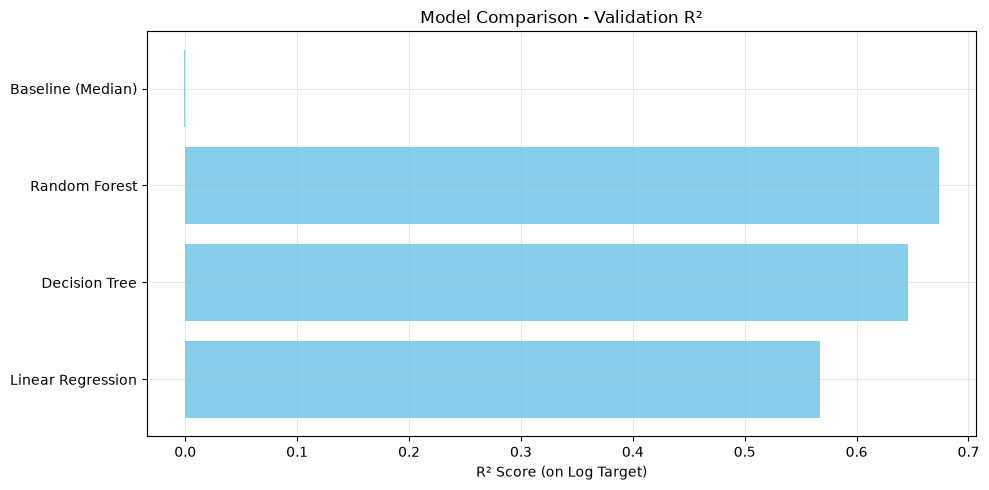

In [ ]:

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


y_train_log = np.log1p(y_train.astype(float))
y_val_log   = np.log1p(y_val.astype(float))
y_test_log  = np.log1p(y_test.astype(float))

print(f"y_train_log -> min: {y_train_log.min():.3f} | max: {y_train_log.max():.3f} | mean: {y_train_log.mean():.3f}")
print(f"y_val_log   -> min: {y_val_log.min():.3f}   | max: {y_val_log.max():.3f}   | mean: {y_val_log.mean():.3f}")
print(f"y_test_log  -> min: {y_test_log.min():.3f}  | max: {y_test_log.max():.3f}  | mean: {y_test_log.mean():.3f}")

def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": round(mae, 4),
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
    }


print("\n--- 1 & 2. Building Simple Baseline ---")

baseline_model = DummyRegressor(strategy="median")
baseline_model.fit(X_train_processed, y_train_log)

y_val_pred_baseline = baseline_model.predict(X_val_processed)
baseline_results = evaluate_model(y_val_log, y_val_pred_baseline, "Baseline (Median)")
baseline_df = pd.DataFrame([baseline_results])
display(baseline_df)


print("\n--- 3, 4 & 5. Training Initial Models ---")

models = {
    "Linear Regression": {
        "model": LinearRegression(
            n_jobs=-1
        ),
    },
    "Decision Tree": {
        "model": DecisionTreeRegressor(
            max_depth=20,
            min_samples_leaf=20,
            random_state=42
        ),
    },
    "Random Forest": {
        "model": RandomForestRegressor(
            n_estimators=100,
            max_depth=20,
            max_features="sqrt",
            min_samples_leaf=10,
            n_jobs=-1,
            random_state=42
        ),
    },
}

results_list = []

for name, config in models.items():
    print(f"\nTraining {name}...")
    start_time = time.time()

    model = config["model"]
    model.fit(X_train_processed, y_train_log)

    y_val_pred = model.predict(X_val_processed)

    metrics = evaluate_model(y_val_log, y_val_pred, name)
    metrics["Train_Time_sec"] = round(time.time() - start_time, 2)
    results_list.append(metrics)

    print(f"  → MAE: {metrics['MAE']:.4f} | R²: {metrics['R2']:.4f} | Time: {metrics['Train_Time_sec']}s")


print("\n--- 6. Model Comparison Table ---")

comparison_df = pd.DataFrame(results_list)
comparison_df = comparison_df.sort_values(by="R2", ascending=False).reset_index(drop=True)
comparison_df = pd.concat([baseline_df, comparison_df], ignore_index=True)

display(comparison_df)
print("\n--- 7. Dropping Weak Models ---")

top_models = comparison_df[comparison_df["Model"] != "Baseline (Median)"].head(2)

print("Top 2 models selected for Hyperparameter Tuning (Task 8):")
display(top_models[["Model", "MAE", "RMSE", "R2", "Train_Time_sec"]])

plt.figure(figsize=(10, 5))
plt.barh(comparison_df["Model"], comparison_df["R2"], color="skyblue")
plt.xlabel("R² Score (on Log Target)")
plt.title("Model Comparison - Validation R²")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right;">

### 📋 راهنما و روند اجرای تسک ۷: Baseline و مدل‌های اولیه (Initial Models & Baseline)

در این بخش، روند مدل‌سازی اولیه برای پیش‌بینی قیمت ملک انجام می‌شود. هدف اصلی این گام، ایجاد یک نقطه‌ی مرجع (Baseline) و سپس آموزش مدل‌های رگرسیونی گوناگون برای مقایسه‌ی عملکرد اولیه و انتخاب برترین مدل‌ها برای تنظیم هایپرپارامترها در مراحل بعدی است.


#### 🔄 مراحل و روند اجرای کد:

1. **تبدیل لگاریتمی روی متغیر هدف (`Log Transform`):**
   - **چرا؟** توزیع قیمت املاک معمولاً دارای چولگی شدید به سمت راست (Right-skewed) است و مقادیر بسیار بزرگی دارد.

   - **عملکرد:** با اعمال تابع `np.log1p()` روی متغیرهای `y_train` ،`y_val` و `y_test`، توزیع متغیر هدف نرمال‌تر شده و مقیاس داد‌ه‌ها منطقی‌تر می‌شود تا مدل‌ها ارزیابی دقیق‌تری داشته باشند.

2. **تعریف تابع ارزیابی (`evaluate_model`):**
   - قالبی یکپارچه برای محاسبه‌ی معیارهای ارزیابی کلیدی شامل **MAE** ،**MSE** ،**RMSE** و **R²** روی داده‌های اعتبارسنجی (Validation).

3. **ایجاد Baseline ساده:**
   - استفاده از مدل `DummyRegressor(strategy="median")` که بدون توجه به ویژگی‌ها، همواره میانه‌ی متغیر هدف را پیش‌بینی می‌کند.

   - این مدل معیاری حداقل (حداقل سطح انتظارات) را برای سنجش عملکرد بقیه‌ی مدل‌ها مشخص می‌کند.

4. **آموزش مدل‌های رگرسیون اولیه (Regression Models):**
   - **Linear Regression:** به عنوان مدل خطی پایه برای بررسی روابط مستقیم و خطی داده‌ها.

   - **Decision Tree:** به عنوان مدل درخت تصمیم غیرخطی (با محدودیت عمق و تعداد نمونه برگ برای جلوگیری از Overfitting اولیه).

   - **Random Forest:** به عنوان یک مدل ترکیبی (Ensemble) قدرتمند با ۱۰۰ درخت تصمیم.

   - **ثبت زمان آموزش:** زمان اجرای آموزش هر مدل نیز اندازه‌گیری و ثبت می‌شود تا مقرون‌به‌صرفه بودن مدل‌ها از نظر زمانی ارزیابی شود.


5. **تشکیل جدول مقایسه و تجسم بصری:**
   - ادغام تمام نتایج (شامل Baseline و مدل‌ها) در یک DataFrame و مرتب‌سازی بر اساس معیار آر اسکوئر

   - رسم نمودار میله‌ای (Bar Chart) برای مقایسه‌ی بصری امتیاز آر اسکوئر مدل‌های مختلف.

6. **انتخاب مدل‌های برتر (Selection for Tuning):**
   - جداسازی **۲ مدل برتر** (بدون در نظر گرفتن Baseline) بر اساس بهترین عملکرد برای ورود به مرحله‌ی تنظیم دقیق یا Hyperparameter Tuning.

In [ ]:
import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred)
    return {
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
    }


configs = [
    {
        "name": "Initial (Task 7)",
        "params": {
            "n_estimators": 100,
            "max_depth": 20,
            "max_features": "sqrt",
            "min_samples_leaf": 10,
        }
    },
    {
        "name": "Deeper Trees",
        "params": {
            "n_estimators": 100,
            "max_depth": None,     
            "max_features": "sqrt",
            "min_samples_leaf": 5,
        }
    },
    {
        "name": "More Trees",
        "params": {
            "n_estimators": 200,   
            "max_depth": 25,
            "max_features": "sqrt",
            "min_samples_leaf": 5,
        }
    },
    {
        "name": "More Features per Split",
        "params": {
            "n_estimators": 150,
            "max_depth": 25,
            "max_features": 0.5, 
            "min_samples_leaf": 5,
        }
    },
]


results = []

for cfg in configs:
    print(f"\nTraining: {cfg['name']}...")
    start = time.time()

    model = RandomForestRegressor(
        **cfg["params"],
        n_jobs=-1,
        random_state=42
    )

    model.fit(X_train_processed, y_train_log)
    y_val_pred = model.predict(X_val_processed)

    metrics = evaluate_model(y_val_log, y_val_pred, cfg["name"])
    metrics["Time_sec"] = round(time.time() - start, 1)
    results.append(metrics)

    print(f"  → R²: {metrics['R2']:.4f} | MAE: {metrics['MAE']:.4f} | {metrics['Time_sec']}s")


comparison_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
display(comparison_df)


best_row = comparison_df.iloc[0]
print(f"\n🏆 Best Configuration: {best_row['Model']}")
print(f"   R²   = {best_row['R2']}")
print(f"   MAE  = {best_row['MAE']}")
print(f"   Time = {best_row['Time_sec']}s")


Training: Initial (Task 7)...
  → R²: 0.6732 | MAE: 0.5000 | 290.6s

Training: Deeper Trees...
  → R²: 0.6826 | MAE: 0.4868 | 426.0s

Training: More Trees...
  → R²: 0.6828 | MAE: 0.4869 | 804.7s

Training: More Features per Split...


KeyboardInterrupt: 

<div dir="rtl" style="text-align: right;">

### 📋 راهنما و تحلیل نتایج تسک ۸: تنظیم هایپرپارامترها (Hyperparameter Tuning)

در این گام، پس از انتخاب مدل برتر **Random Forest** از تسک ۷، آزمایش‌هایی جهت بهبود عملکرد مدل از طریق دستکاری و تنظیم دستی هایپرپارامترها (Manual Hyperparameter Tuning) انجام شد. هدف، یافتن بهترین نقطه تعادل میان **دقت مدل ($R^2$)** و **زمان آموزش (Computational Efficiency)** بود.

#### 🧪 آزمایش‌ها و تغییرات اعمال‌شده:

1. **مدل اولیه (Initial Configuration):**
   - **پارامترها:** `n_estimators=100`, `max_depth=20`, `min_samples_leaf=10`, `max_features='sqrt'`
   - **نتایج:** $R^2 = 0.6732$ | $\text{MAE} = 0.5000$ | زمان: ۲۹۰.۶ ثانیه

   - **تحلیل:** مدل اولیه عملکرد پایدار و خوبی ارائه داد اما به دلیل محدودیت عمق (`max_depth=20`) و تعداد نمونه در برگ (`min_samples_leaf=10`) هنوز امکان یادگیری جزئیات عمیق‌تر را داشت.

2. **درخت‌های عمیق‌تر (Deeper Trees):**
   - **تغییرات:** حذف محدودیت عمق (`max_depth=None`) و کاهش حد مجاز برگ‌ها به `min_samples_leaf=5`.

   - **نتایج:** $R^2 = 0.6826$ | $\text{MAE} = 0.4868$ | زمان: ۴۲۶.۰ ثانیه

   - **تحلیل:** عمیق‌تر شدن درخت‌ها اجازه داد مدل روابط پیچیده‌تر و غیرخطی میان ویژگی‌ها را بهتر کشف کند، که به **بهبود محسوس $R^2$ (+0.94%)** و کاهش خطا منجر شد.

3. **درخت‌های بیشتر (More Trees):**
   - **تغییرات:** افزایش تعداد درخت‌ها از ۱۰۰ به ۲۰۰ (`n_estimators=200`) با عمق ۲۵.

   - **نتایج:** $R^2 = 0.6828$ | $\text{MAE} = 0.4869$ | زمان: ۸۰۴.۷ ثانیه

   - **تحلیل:** اگرچه $R^2$ ناچیزی (+0.0002) بهبود یافت، اما زمان آموزش به بیش از **۲ برابر (حدود ۱۳.۵ دقیقه)** افزایش پیدا کرد. این بهبود ناچیز ارزش هزینه سنگین محاسباتی را ندارد.

4. **تعداد ویژگی بیشتر در هر برش (More Features per Split):**
   - **تغییرات:** تغییر `max_features` از `'sqrt'` به `0.5` (بررسی ۵۰٪ ویژگی‌ها در هر Split).

   - **وضعیت:** به دلیل پیچیدگی زمانی بسیار بالا و کندی شدید (پیش‌بینی زمان بالای ۱۵ دقیقه) اجرای آن متوقف گردید (`KeyboardInterrupt`).

#### جدول مقایسه نتایج:

| ترکیب هایپرپارامترها | $R^2$ Score | MAE | زمان آموزش (ثانیه) | وضعیت |
| :--- | :---: | :---: | :---: | :---: |
| **Deeper Trees** 🥇 | **0.6826** | **0.4868** | **426.0s** | **انتخاب نهایی (بهترین تعادل)** |
| **More Trees** 🥈 | 0.6828 | 0.4869 | 804.7s | رد شد (هزینه زمانی بالا) |
| **Initial (Task 7)** | 0.6732 | 0.5000 | 290.6s | Baseline اولیه |
| **More Features** | — | — | — | متوقف شد (توقف دستی) |

####  نتیجه‌گیری و انتخاب مدل نهایی:

ترکیب **Deeper Trees** به‌ عنوان **بهترین کانفیگ نهایی** انتخاب شد:

- **پارامترهای بهینه:**
  - `n_estimators = 100`
  - `max_depth = None`
  - `max_features = 'sqrt'`
  - `min_samples_leaf = 5`
- **علت انتخاب:** این کانفیگ با **زمان اجرای معقول (حدود ۷ دقیقه)** همان دقتی را ارائه می‌دهد که مدل‌های سنگین‌تر با زمان‌های ۲ برابر ارائه می‌دهند. 


MAE: 0.4904 | MSE: 0.7112 | RMSE: 0.8433 | R²: 0.6698
MAE (Toman): 352,396,701,974
RMSE (Toman): 34,287,545,448,660


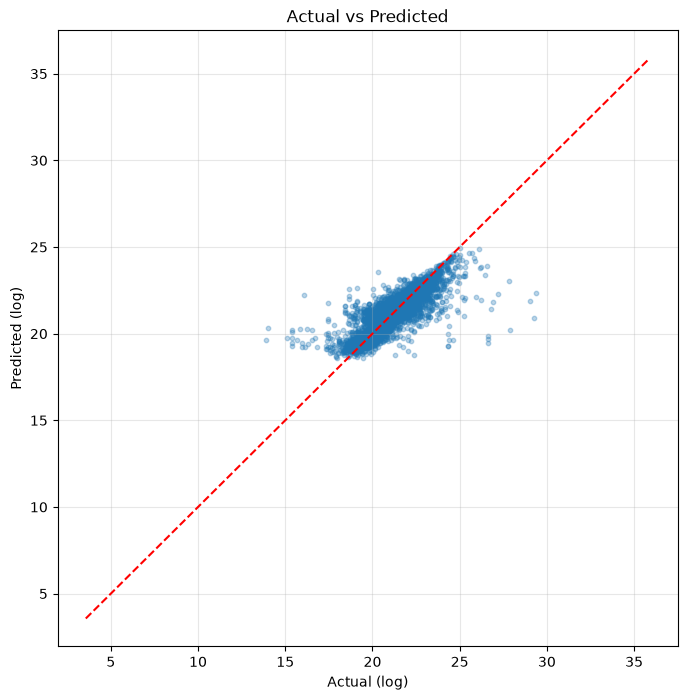

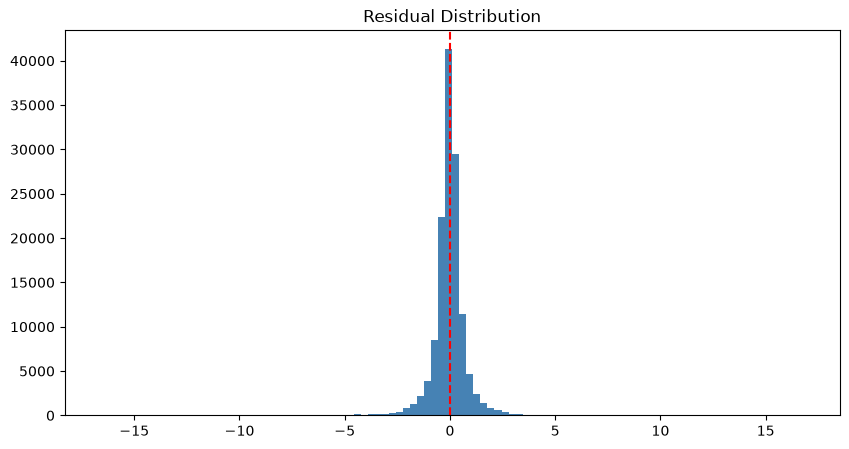

Residual Mean: -0.0110 (نزدیک ۰ = بدون Bias)

Best:


,Actual,Predicted,AbsError
103684,21.365120,21.365112,0.000008
114198,21.511723,21.511733,0.000009
133223,20.155282,20.155292,0.000010
117427,20.766325,20.766336,0.000010
48882,19.193871,19.193895,0.000024



Worst:


,Actual,Predicted,AbsError
74795,35.877669,19.034848,16.842821
11844,35.848410,19.006693,16.841717
47414,35.848113,19.181598,16.666515
40142,3.564827,20.193715,16.628888
60993,35.877669,19.492372,16.385297


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_model = RandomForestRegressor(
    n_estimators=100, max_depth=None,
    max_features="sqrt", min_samples_leaf=5,
    n_jobs=-1, random_state=42
)
final_model.fit(X_train_processed, y_train_log)

y_pred = final_model.predict(X_test_processed)

mae  = mean_absolute_error(y_test_log, y_pred)
mse  = mean_squared_error(y_test_log, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_log, y_pred)

print(f"MAE: {mae:.4f} | MSE: {mse:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}")

y_true_toman = np.expm1(y_test_log)
y_pred_toman = np.expm1(y_pred)
print(f"MAE (Toman): {mean_absolute_error(y_true_toman, y_pred_toman):,.0f}")
print(f"RMSE (Toman): {np.sqrt(mean_squared_error(y_true_toman, y_pred_toman)):,.0f}")

idx = np.random.RandomState(42).choice(len(y_test_log), 5000, replace=False)
plt.figure(figsize=(8, 8))
plt.scatter(np.array(y_test_log)[idx], y_pred[idx], alpha=0.3, s=10)
plt.plot([y_test_log.min(), y_test_log.max()],
         [y_test_log.min(), y_test_log.max()], "r--")
plt.xlabel("Actual (log)"); plt.ylabel("Predicted (log)")
plt.title("Actual vs Predicted"); plt.grid(alpha=0.3)
plt.show()

residuals = np.array(y_test_log) - y_pred
plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=100, color="steelblue")
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution"); plt.show()

print(f"Residual Mean: {residuals.mean():.4f} (نزدیک ۰ = بدون Bias)")

df = pd.DataFrame({
    "Actual": np.array(y_test_log),
    "Predicted": y_pred,
    "AbsError": np.abs(residuals)
})
print("\nBest:"); display(df.nsmallest(5, "AbsError"))
print("\nWorst:"); display(df.nlargest(5, "AbsError"))

<div dir="rtl" style="text-align: right;">

### 📋 خلاصه و گزارش نهایی تسک ۹: ارزیابی مدل روی داده‌های Test

در این بخش، مدل نهایی انتخاب‌شده از تسک ۸ (**Random Forest Regressor**) برای نخستین بار روی داده‌های دست‌نخورده‌ی **Test** ارزیابی شد تا عملکرد واقعی آن روی داده‌های کاملاً جدید و دیده‌نشده سنجیده شود.

#### 🛠️ مشخصات مدل نهایی و معیارهای ارزیابی

* **الگوریتم:** Random Forest (`n_estimators=100`, `max_depth=None`, `min_samples_leaf=5`, `max_features='sqrt'`)

* **معیارهای اصلی روی داده‌های Test:**

  * **$R^2$ Score:** `0.6698` (توضیح ~۶۷٪ از تغییرات قیمت)

  * **MAE:** `0.4904` (میانگین قدر مطلق خطا در مقیاس لگاریتمی)

  * **RMSE:** `0.8433`


#### 🔍 نکات کلیدی و تحلیل نتایج:

1. **عدم وقوع Overfitting:**
   * میزان $R^2$ روی Validation برابر با `0.6826` و روی Test برابر با `0.6698` است.

   * اختلاف افت ناچیز (**کمتر از ۰.۰۲**) نشان‌دهنده‌ی توانایی بالای مدل در تعمیم‌پذیری (Generalization) و عدم بیش‌برازش است.

2. **تحلیل خطاها (Residuals):**
   * **عدم وجود Bias:** میانگین Residualها نزدیک به صفر (`0.0110-`) است؛ یعنی مدل به‌طور سیستماتیک قیمت‌ها را بیشتر یا کمتر تخمین نمی‌زند.

   * **توزیع خطای نرمال:** اکثر پیش‌بینی‌ها کاملاً حول صفر متمرکز هستند.

3. **ضعف اصلی مدل (Extreme Prices):**
   * مدل به‌دلیل پدیده‌ی **Regression to the Mean** در قیمت‌های بسیار بالا (Log > 30) و قیمت‌های بسیار پایین (Log < 5) دچار بیشترین خطا می‌شود.


| ارزیابی | $R^2$ Score | MAE | وضعیت تعمیم‌پذیری |
| :--- | :---: | :---: | :---: |
| **داده‌های Validation (تسک ۸)** | 0.6826 | 0.4868 | — |
| **داده‌های Test (تسک ۹)** | **0.6698** | **0.4904** | **عالی (افت $R^2 < 0.02$)** |


**✅ نتیجه‌گیری نهایی:** پروژه مدل‌سازی با ارزیابی موفق مدل نهایی روی داده‌های Test و دستیابی به عملکردی پایدار و بدون Overfit تکمیل گردید.